In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


## Part A — Static graphene device and leads

### Cell A1: Imports and shared parameters

In [2]:
# ============================================================
# PART A — STATIC GRAPHENE DEVICE AND LEADS
#Cell A1: Imports and shared parameters
# ============================================================

# -----------------------------
# Energy unit
# -----------------------------
# All energies are measured in units of graphene hopping gamma.
# Physical graphene: gamma ≈ 2.7 eV.
gamma = 1.0

# -----------------------------
# ZGNR geometry
# -----------------------------
Ny = 29                 # ribbon width; one unit cell has 2*Ny atoms
N_orb = 2 * Ny          # number of orbitals per lead/device slice

# Number of longitudinal unit cells in the finite irradiated region.
#
# Nx = 30 is motivated by the finite-length geometry used in the paper,

Nx = 30

# Total number of orbitals in the central graphene region
N_device = Nx * N_orb

# -----------------------------
# Numerical tolerances
# -----------------------------
eta = 1e-8              # small imaginary broadening for retarded GFs

print("ZGNR width Ny                  =", Ny)
print("Atoms (Orbitals) per longitudinal cell =", N_orb)
print("Number of device cells Nx      =", Nx)
print("Total device orbitals          =", N_device)

ZGNR width Ny                  = 29
Atoms (Orbitals) per longitudinal cell = 58
Number of device cells Nx      = 30
Total device orbitals          = 1740


### Cell A2: Static ZGNR unit-cell Hamiltonian

In [3]:
# ============================================================
# Cell A2: Static ZGNR unit-cell Hamiltonian
# ============================================================

def zgnr_unit_cell(Ny, gamma=1.0):
    """
    Construct the static nearest-neighbor tight-binding matrices
    for a zigzag graphene nanoribbon.

    Returns
    -------
    H00 : ndarray
        Intracell Hamiltonian of one longitudinal ZGNR slice.

    H01 : ndarray
        Coupling from one longitudinal slice to the next.

    Notes
    -----
    One slice contains:
        A_0, B_0, A_1, B_1, ..., A_(Ny-1), B_(Ny-1)

    so its dimension is 2*Ny.
    """

    n_orb = 2 * Ny

    H00 = np.zeros((n_orb, n_orb), dtype=complex)
    H01 = np.zeros((n_orb, n_orb), dtype=complex)

    def A(j):
        """Index of sublattice-A orbital at transverse position j."""
        return 2 * j

    def B(j):
        """Index of sublattice-B orbital at transverse position j."""
        return 2 * j + 1

    # --------------------------------------------------------
    # Nearest-neighbor bonds inside one longitudinal unit cell
    # --------------------------------------------------------

    # A_j <-> B_j
    for j in range(Ny):
        H00[A(j), B(j)] = -gamma
        H00[B(j), A(j)] = -gamma

    # B_j <-> A_(j+1)
    for j in range(Ny - 1):
        H00[A(j + 1), B(j)] = -gamma
        H00[B(j), A(j + 1)] = -gamma

    # --------------------------------------------------------
    # Coupling between neighboring longitudinal unit cells
    # --------------------------------------------------------

    for j in range(Ny):
        H01[A(j), B(j)] = -gamma

    return H00, H01


# Construct the matrices only once
H00, H01 = zgnr_unit_cell(Ny, gamma)

print("H00 shape =", H00.shape)
print("H01 shape =", H01.shape)

print(
    "Hermiticity error of H00 =",
    np.linalg.norm(H00 - H00.conj().T)
)

H00 shape = (58, 58)
H01 shape = (58, 58)
Hermiticity error of H00 = 0.0


### Cell A3: Finite central graphene region

In [4]:
# ============================================================
# Cell A3: Finite central graphene region
# ============================================================

def build_finite_zgnr(H00, H01, Nx):
    """
    Construct a finite ZGNR consisting of Nx longitudinal slices.

    Parameters
    ----------
    H00 : ndarray
        Intracell Hamiltonian.

    H01 : ndarray
        Coupling from slice x to slice x+1.

    Nx : int
        Number of longitudinal slices.

    Returns
    -------
    H_device : ndarray
        Static Hamiltonian of the finite central region.
    """

    n_orb = H00.shape[0]
    n_total = Nx * n_orb

    H_device = np.zeros(
        (n_total, n_total),
        dtype=complex
    )

    # Intracell blocks
    for x in range(Nx):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        H_device[sl_x, sl_x] = H00

    # Couplings between neighboring longitudinal slices
    for x in range(Nx - 1):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        sl_next = slice(
            (x + 1) * n_orb,
            (x + 2) * n_orb
        )

        H_device[sl_x, sl_next] = H01
        H_device[sl_next, sl_x] = H01.conj().T

    return H_device


H_device_static = build_finite_zgnr(
    H00,
    H01,
    Nx
)

# ------------------------------------------------------------
# Contact orbitals
# ------------------------------------------------------------
# The first longitudinal slice couples to the left lead.
left_contact = np.arange(
    0,
    N_orb
)

# The last longitudinal slice couples to the right lead.
right_contact = np.arange(
    (Nx - 1) * N_orb,
    Nx * N_orb
)

print("Static device shape =", H_device_static.shape)

print(
    "Device Hermiticity error =",
    np.linalg.norm(
        H_device_static
        - H_device_static.conj().T
    )
)

print("Number of left-contact orbitals  =", len(left_contact))
print("Number of right-contact orbitals =", len(right_contact))

Static device shape = (1740, 1740)
Device Hermiticity error = 0.0
Number of left-contact orbitals  = 58
Number of right-contact orbitals = 58


### Cell A4: Optional check of the static ZGNR band structure

In [5]:
# ============================================================
# Cell A4: Optional check of the static ZGNR band structure
# ============================================================

def static_bloch_hamiltonian(k, H00, H01):
    """
    Static Bloch Hamiltonian of an infinite ZGNR.

    k is the dimensionless longitudinal Bloch momentum.
    """

    return (
        H00
        + H01 * np.exp(1j * k)
        + H01.conj().T * np.exp(-1j * k)
    )


Nk_check = 300

k_values = np.linspace(
    -np.pi,
    np.pi,
    Nk_check,
    endpoint=False
)

static_bands = np.zeros(
    (Nk_check, N_orb)
)

for ik, k in enumerate(k_values):

    Hk = static_bloch_hamiltonian(
        k,
        H00,
        H01
    )

    static_bands[ik] = np.linalg.eigvalsh(Hk)


plt.figure(figsize=(6, 4))

for band_index in range(N_orb):

    plt.plot(
        k_values / np.pi,
        static_bands[:, band_index],
        lw=0.7
    )

plt.xlabel(r"$k_x/\pi$")
plt.ylabel(r"$E/\gamma$")
plt.title(rf"Static ZGNR check, $N_y={Ny}$")

plt.xlim(-1, 1)
plt.ylim(-3, 3)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## Part B — Driven graphene Floquet system

### Cell B1: Light and Floquet parameters

In [6]:
# ============================================================
# PART B — DRIVEN GRAPHENE FLOQUET SYSTEM
# Cell B1: Light and Floquet parameters
# ============================================================

# Circularly polarized light
z = 0.5                  # dimensionless light amplitude
omega = 3.0              # photon energy hbar*omega in units of gamma
#Here omega represents ℏω in units of γ, not an angular frequency in inverse second

# Floquet truncation
Nph = 4                  # begin with 1 for testing
sectors = np.arange(-Nph, Nph + 1)

# Number of phase points used for numerical Fourier integration
#this has no use in bessel fucntion mehtod
#N_phase = 200

# Small imaginary part in retarded Green functions
eta_floquet = 1e-6

# Floquet dimensions
Ndev = Nx * N_orb
NF = len(sectors) * Ndev

print("Light amplitude z       =", z)
print("Photon energy hbar*w    =", omega, "gamma")
print("Floquet sectors         =", sectors)
print("Static device dimension =", Ndev)
print("Floquet dimension       =", NF)

Light amplitude z       = 0.5
Photon energy hbar*w    = 3.0 gamma
Floquet sectors         = [-4 -3 -2 -1  0  1  2  3  4]
Static device dimension = 1740
Floquet dimension       = 15660


### Cell B2: Driven ZGNR unit-cell blocks

In [7]:
# ============================================================
# Cell B2: Driven ZGNR unit-cell blocks
# ============================================================

def driven_zgnr_unit_cell(phi, Ny, gamma=1.0, z=0.5):
    """
    Construct the time-dependent ZGNR blocks at phase phi = omega*t.

    Parameters
    ----------
    phi : float
        Dimensionless driving phase omega*t.

    Ny : int
        Ribbon width parameter.

    gamma : float
        Nearest-neighbor hopping.

    z : float
        Dimensionless circular-light amplitude.

    Returns
    -------
    H00_phi : ndarray
        Driven intracell Hamiltonian.

    H01_phi : ndarray
        Driven coupling from one longitudinal cell to the next.
    """

    n_orb = 2 * Ny

    H00_phi = np.zeros((n_orb, n_orb), dtype=complex)
    H01_phi = np.zeros((n_orb, n_orb), dtype=complex)

    def A(j):
        return 2 * j

    def B(j):
        return 2 * j + 1

    # Dimensionless vector-potential direction
    Ax = np.cos(phi)
    Ay = np.sin(phi)

    def peierls_phase(dx, dy):
        """
        exp[i 2z A(phi).r_ij]
        """
        return np.exp(
            1j * 2.0 * z * (Ax * dx + Ay * dy)
        )

    # Three nearest-neighbor graphene bond directions
    d1 = (0.0, 1.0)
    d2 = (np.sqrt(3.0) / 2.0, -0.5)
    d3 = (-np.sqrt(3.0) / 2.0, -0.5)

    # Bond type 1: A_j <-> B_j inside one cell
    hopping_1 = -gamma * peierls_phase(*d1)

    for j in range(Ny):
        H00_phi[A(j), B(j)] += hopping_1
        H00_phi[B(j), A(j)] += np.conj(hopping_1)

    # Bond type 2: B_j <-> A_(j+1) inside one cell
    hopping_2 = -gamma * peierls_phase(*d2)

    for j in range(Ny - 1):
        H00_phi[A(j + 1), B(j)] += hopping_2
        H00_phi[B(j), A(j + 1)] += np.conj(hopping_2)

    # Bond type 3: coupling to the next longitudinal cell
    hopping_3 = -gamma * peierls_phase(*d3)

    for j in range(Ny):
        H01_phi[A(j), B(j)] += hopping_3

    return H00_phi, H01_phi

#This is the essential 2D feature: the Peierls phase depends on the direction of each graphene bond

### Cell B3: Finite driven ZGNR Hamiltonian H(phi)

In [8]:
# ============================================================
# Cell B3: Finite driven ZGNR Hamiltonian H(phi)
# ============================================================

def build_driven_device(phi, Nx, Ny, gamma=1.0, z=0.5):
    """
    Construct the finite irradiated graphene Hamiltonian H(phi).
    """

    H00_phi, H01_phi = driven_zgnr_unit_cell(
        phi=phi,
        Ny=Ny,
        gamma=gamma,
        z=z
    )

    n_orb = 2 * Ny
    n_device = Nx * n_orb

    H_phi = np.zeros(
        (n_device, n_device),
        dtype=complex
    )

    # Intracell blocks
    for x in range(Nx):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        H_phi[sl_x, sl_x] = H00_phi

    # Coupling between adjacent longitudinal cells
    for x in range(Nx - 1):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        sl_next = slice(
            (x + 1) * n_orb,
            (x + 2) * n_orb
        )

        H_phi[sl_x, sl_next] = H01_phi
        H_phi[sl_next, sl_x] = H01_phi.conj().T

    return H_phi

#### Check Hermiticity at one arbitrary driving phase

In [9]:
# Check Hermiticity at one arbitrary driving phase

H_test = build_driven_device(
    phi=0.37,
    Nx=Nx,
    Ny=Ny,
    gamma=gamma,
    z=z
)

print(
    "Hermiticity error of H(phi) =",
    np.linalg.norm(H_test - H_test.conj().T)
)

Hermiticity error of H(phi) = 0.0


### Cell B4 (Bessel version): Analytic Fourier components H_m

B4 is now based on Bessel functions

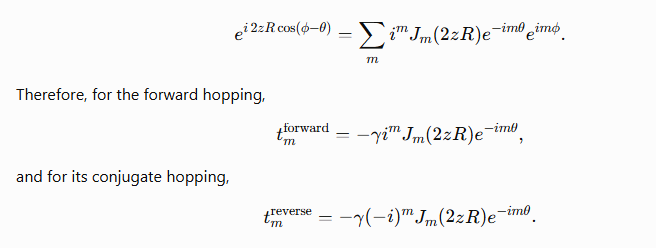

In [10]:
# ============================================================
# Cell B4 (Bessel version): Analytic Fourier components H_m
# via Jacobi-Anger expansion, replacing numerical phase-averaging.
# ============================================================

from scipy.special import jv  # Bessel functions of the first kind

def unit_cell_fourier_bessel(Ny, gamma=1.0, z=0.5, Mmax=2):
    """
    Analytic Fourier components H0_m, H1_m of the driven ZGNR
    unit-cell blocks, using the Jacobi-Anger expansion instead
    of numerical time-averaging.

    For a bond direction (dx, dy) with R = sqrt(dx^2+dy^2) and
    theta = atan2(dy, dx), the Peierls phase

        exp[i 2z (cos(phi) dx + sin(phi) dy)]
      = exp[i (2zR) cos(phi - theta)]

    has the exact expansion (paper's Eq. 6b):

        = sum_m  i^m J_m(2zR) e^{-im theta} e^{im phi}

    so the m-th Fourier component of a hopping term
    -gamma * peierls_phase(phi) is

        -gamma * i^m * J_m(2zR) * exp(-i m theta)

    and the m-th component of its Hermitian-conjugate hopping
    (used on the reversed bond) is

        -gamma * (-i)^m * J_m(2zR) * exp(-i m theta)

    (same J_m and same theta, only i^m -> (-i)^m).
    """

    n_orb = 2 * Ny

    def A(j):
        return 2 * j

    def B(j):
        return 2 * j + 1

    # Same three nearest-neighbor bond directions as in B2
    bonds = {
        "d1": (0.0, 1.0),
        "d2": (np.sqrt(3.0) / 2.0, -0.5),
        "d3": (-np.sqrt(3.0) / 2.0, -0.5),
    }

    R = {}
    theta = {}
    for name, (dx, dy) in bonds.items():
        R[name] = np.hypot(dx, dy)
        theta[name] = np.arctan2(dy, dx)

    H0m = {
        m: np.zeros((n_orb, n_orb), dtype=complex)
        for m in range(-Mmax, Mmax + 1)
    }
    H1m = {
        m: np.zeros((n_orb, n_orb), dtype=complex)
        for m in range(-Mmax, Mmax + 1)
    }

    for m in range(-Mmax, Mmax + 1):

        # --- Bond d1: A_j <-> B_j inside the cell ---
        x1 = 2.0 * z * R["d1"]
        fwd1 = -gamma * (1j**m) * jv(m, x1) * np.exp(-1j * m * theta["d1"])
        conj1 = -gamma * ((-1j)**m) * jv(m, x1) * np.exp(-1j * m * theta["d1"])

        for j in range(Ny):
            H0m[m][A(j), B(j)] += fwd1
            H0m[m][B(j), A(j)] += conj1

        # --- Bond d2: A_{j+1} <-> B_j inside the cell ---
        x2 = 2.0 * z * R["d2"]
        fwd2 = -gamma * (1j**m) * jv(m, x2) * np.exp(-1j * m * theta["d2"])
        conj2 = -gamma * ((-1j)**m) * jv(m, x2) * np.exp(-1j * m * theta["d2"])

        for j in range(Ny - 1):
            H0m[m][A(j + 1), B(j)] += fwd2
            H0m[m][B(j), A(j + 1)] += conj2

        # --- Bond d3: coupling to the next unit cell ---
        x3 = 2.0 * z * R["d3"]
        fwd3 = -gamma * (1j**m) * jv(m, x3) * np.exp(-1j * m * theta["d3"])

        for j in range(Ny):
            H1m[m][A(j), B(j)] += fwd3
            # H1's Hermitian partner lives in H1^dagger at the device
            # level (handled during device assembly), same as in B3.

    return H0m, H1m


def device_fourier_components(Nx, Ny, gamma=1.0, z=0.5, Mmax=2):
    """
    Bessel-based drop-in replacement for the original
    device_fourier_components(). Same signature, same output
    shape/keys: dict {m: (N_device, N_device) ndarray}.

    No N_phase / phase sampling needed.
    """

    n_orb = 2 * Ny
    n_device = Nx * n_orb

    H0m, H1m = unit_cell_fourier_bessel(Ny, gamma=gamma, z=z, Mmax=Mmax)

    H_fourier = {
        m: np.zeros((n_device, n_device), dtype=complex)
        for m in range(-Mmax, Mmax + 1)
    }

    for m in range(-Mmax, Mmax + 1):

        # Intracell blocks (same H0_m on every cell)
        for x in range(Nx):
            sl = slice(x * n_orb, (x + 1) * n_orb)
            H_fourier[m][sl, sl] = H0m[m]

        # Intercell couplings (same H1_m between every neighboring pair)
        for x in range(Nx - 1):
            sl_x = slice(x * n_orb, (x + 1) * n_orb)
            sl_next = slice((x + 1) * n_orb, (x + 2) * n_orb)

            H_fourier[m][sl_x, sl_next] = H1m[m]

    # H1^dagger contributes to H_{-m} at the (next, x) block —
    # add it via the Hermiticity of the full periodic H(t):
    # H_{-m} = H_m^dagger for the WHOLE Hamiltonian, so instead of
    # deriving H1^dagger's Fourier series separately, enforce it directly:
    for m in range(-Mmax, Mmax + 1):
        for x in range(Nx - 1):
            sl_x = slice(x * n_orb, (x + 1) * n_orb)
            sl_next = slice((x + 1) * n_orb, (x + 2) * n_orb)
            H_fourier[m][sl_next, sl_x] = H_fourier[-m][sl_x, sl_next].conj().T

    return H_fourier

In [11]:
# Sanity check: reconstruct H(phi) from Bessel H_m's and compare
# against the exact driven Hamiltonian from B2/B3.

Mmax_check = 10  # generous truncation for the check itself

H_fourier_check = device_fourier_components(
    Nx=Nx, Ny=Ny, gamma=gamma, z=z, Mmax=Mmax_check
)

phi_test = 0.83  # arbitrary test phase

H_reconstructed = sum(
    H_fourier_check[m] * np.exp(1j * m * phi_test)
    for m in range(-Mmax_check, Mmax_check + 1)
)

H_exact = build_driven_device(phi=phi_test, Nx=Nx, Ny=Ny, gamma=gamma, z=z)

print("Max reconstruction error =", np.max(np.abs(H_reconstructed - H_exact)))

Max reconstruction error = 2.3325759691995024e-11


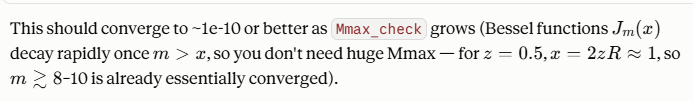

In [12]:
H_fourier = device_fourier_components(
    Nx=Nx, Ny=Ny, gamma=gamma, z=z, Mmax=2 * Nph
)

print("Calculated Fourier orders:")
print(sorted(H_fourier.keys()))

Calculated Fourier orders:
[-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]


### Cell B5: Assemble H_F and Omega_F

In [13]:
# ============================================================
# Cell B5: Assemble H_F and Omega_F
# ============================================================

def assemble_floquet_matrices(
    H_fourier,
    Nph,
    omega
):
    """
    Construct:

        H_F[m,n] = H_(n-m)

    and

        Omega_F[m,m] = m*omega*I

    so that

        G^r(E) = [E I + Omega_F - H_F - Sigma^r]^{-1}.
    """

    sectors = np.arange(-Nph, Nph + 1)

    n_device = H_fourier[0].shape[0]
    n_floquet = len(sectors) * n_device

    HF = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    OmegaF = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    eye_device = np.eye(
        n_device,
        dtype=complex
    )

    for a, m in enumerate(sectors):

        row = slice(
            a * n_device,
            (a + 1) * n_device
        )

        # Photon-energy block
        OmegaF[row, row] = m * omega * eye_device

        for b, n in enumerate(sectors):

            col = slice(
                b * n_device,
                (b + 1) * n_device
            )

            HF[row, col] = H_fourier[n - m]
            #you may retain m-n, but then you must define the expansion as
            #H(t)=q∑​Hq​exp(−iqωt) in B4 instead of ​exp(+iqωt).

    return HF, OmegaF

In [14]:
HF, OmegaF = assemble_floquet_matrices(
    H_fourier=H_fourier,
    Nph=Nph,
    omega=omega
)

print("HF shape     =", HF.shape)
print("OmegaF shape =", OmegaF.shape)

print(
    "Floquet-Hamiltonian Hermiticity error =",
    np.linalg.norm(HF - HF.conj().T)
)

HF shape     = (15660, 15660)
OmegaF shape = (15660, 15660)
Floquet-Hamiltonian Hermiticity error = 0.0


### Cell B6: Static ZGNR lead surface Green function

In [15]:
# ============================================================
# Cell B6: Static ZGNR lead surface Green function
# López–Sancho iterative method
# ============================================================

def sancho_surface_gf(
    E,
    H00,
    H01,
    eta=1e-9,
    max_iter=200,
    tol=1e-12
):
    """
    Surface retarded Green function of a semi-infinite
    periodic lead using the López–Sancho iteration.

    Parameters
    ----------
    E : float
        Energy.

    H00 : ndarray
        Hamiltonian of one lead unit cell.

    H01 : ndarray
        Coupling from cell i to cell i+1.

    eta : float
        Positive infinitesimal for the retarded Green function.

    Returns
    -------
    g_surface : ndarray
        Surface retarded Green function.
    """

    n_orb = H00.shape[0]
    identity = np.eye(n_orb, dtype=complex)

    z_matrix = (E + 1j * eta) * identity

    alpha = H01.copy()
    beta = H01.conj().T.copy()

    epsilon = H00.copy()
    epsilon_surface = H00.copy()

    for iteration in range(max_iter):

        g_bulk = np.linalg.inv(z_matrix - epsilon)

        epsilon_surface_new = (
            epsilon_surface
            + alpha @ g_bulk @ beta
        )

        epsilon_new = (
            epsilon
            + alpha @ g_bulk @ beta
            + beta @ g_bulk @ alpha
        )

        alpha_new = alpha @ g_bulk @ alpha
        beta_new = beta @ g_bulk @ beta

        if (
            np.linalg.norm(alpha_new) < tol
            and np.linalg.norm(beta_new) < tol
        ):
            epsilon_surface = epsilon_surface_new
            break

        epsilon_surface = epsilon_surface_new
        epsilon = epsilon_new
        alpha = alpha_new
        beta = beta_new

    else:
        print(
            f"Warning: López–Sancho did not converge "
            f"after {max_iter} iterations at E={E:.6f}"
        )

    g_surface = np.linalg.inv(
        z_matrix - epsilon_surface
    )

    return g_surface

#### Validate static ZGNR lead self-energy

In [16]:
# ============================================================
# Validate static ZGNR lead self-energy
# ============================================================

E_test = 0.5

# Right-facing surface
g_surface_R = sancho_surface_gf(
    E=E_test,
    H00=H00,
    H01=H01,
    eta=1e-6
)

Sigma_R_test = (
    H01
    @ g_surface_R
    @ H01.conj().T
)

Gamma_R_test = 1j * (
    Sigma_R_test
    - Sigma_R_test.conj().T
)

print("Surface GF shape =", g_surface_R.shape)

print(
    "Gamma_R Hermiticity error =",
    np.linalg.norm(
        Gamma_R_test
        - Gamma_R_test.conj().T
    )
)

print(
    "Minimum eigenvalue of Gamma_R =",
    np.min(np.linalg.eigvalsh(Gamma_R_test))
)

Surface GF shape = (58, 58)
Gamma_R Hermiticity error = 0.0
Minimum eigenvalue of Gamma_R = -7.892937584420095e-16


### Cell B7: Floquet self-energies of static ZGNR leads

In [17]:
# ============================================================
# Cell B7: Floquet self-energies of static ZGNR leads
# ============================================================

def graphene_floquet_self_energies(
    E,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    eta=1e-6
):
    """
    Embed static ZGNR lead self-energies into Floquet space.

    The lead self-energies are diagonal in photon-sector index.
    """

    sectors = np.arange(-Nph, Nph + 1)

    n_orb = H00.shape[0]
    n_device = Nx * n_orb
    n_floquet = len(sectors) * n_device

    SigmaL_F = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    SigmaR_F = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    for a, m in enumerate(sectors):

        sideband_energy = E + m * omega

        # Surface Green functions for right- and left-facing leads
        g_surface_R = sancho_surface_gf(
            sideband_energy,
            H00,
            H01,
            eta=eta
        )

        g_surface_L = sancho_surface_gf(
            sideband_energy,
            H00,
            H01.conj().T,
            eta=eta
        )

        # Self-energy blocks acting on one contact slice
        SigmaR_contact = (
            H01
            @ g_surface_R
            @ H01.conj().T
        )

        SigmaL_contact = (
            H01.conj().T
            @ g_surface_L
            @ H01
        )

        sector_offset = a * n_device

        left_block = slice(
            sector_offset,
            sector_offset + n_orb
        )

        right_block = slice(
            sector_offset + (Nx - 1) * n_orb,
            sector_offset + Nx * n_orb
        )

        SigmaL_F[left_block, left_block] = SigmaL_contact
        SigmaR_F[right_block, right_block] = SigmaR_contact

    return SigmaL_F, SigmaR_F

### Cell B8: Floquet retarded Green function

In [18]:
# ============================================================
# Cell B8: Floquet retarded Green function
# ============================================================

def graphene_floquet_green_function(
    E,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    eta=1e-6
):
    """
    Calculate the full Floquet retarded Green function:

    G^r(E) = [E I + OmegaF - HF - SigmaL - SigmaR]^{-1}
    """

    SigmaL_F, SigmaR_F = graphene_floquet_self_energies(
        E=E,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    n_floquet = HF.shape[0]

    identity_F = np.eye(
        n_floquet,
        dtype=complex
    )

    inverse_green = (
        (E + 1j * eta) * identity_F
        + OmegaF
        - HF
        - SigmaL_F
        - SigmaR_F
    )

    Gr = np.linalg.inv(inverse_green)

    return Gr, SigmaL_F, SigmaR_F

#### Gr shape

In [19]:
# Use a small Nx and Nph before attempting a large calculation.

E_test = 0.0

Gr_test, SigmaL_test, SigmaR_test = (
    graphene_floquet_green_function(
        E=E_test,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta_floquet
    )
)

print("Gr shape =", Gr_test.shape)



Gr shape = (15660, 15660)


### Cell B9: Numerical checks for Floquet Gr and lead broadenings

In [38]:
# ============================================================
# Cell B9: Numerical checks for Floquet Gr and lead broadenings
# ============================================================

print("Gr shape =", Gr_test.shape)

print("Any NaN in Gr =", np.isnan(Gr_test).any())
print("Any Inf in Gr =", np.isinf(Gr_test).any())

GammaL_test = 1j * (
    SigmaL_test - SigmaL_test.conj().T
)

GammaR_test = 1j * (
    SigmaR_test - SigmaR_test.conj().T
)

print(
    "GammaL Hermiticity error =",
    np.linalg.norm(
        GammaL_test - GammaL_test.conj().T
    )
)

print(
    "GammaR Hermiticity error =",
    np.linalg.norm(
        GammaR_test - GammaR_test.conj().T
    )
)

eig_GammaL = np.linalg.eigvalsh(GammaL_test)
eig_GammaR = np.linalg.eigvalsh(GammaR_test)

print("Minimum eigenvalue GammaL =", eig_GammaL.min())
print("Minimum eigenvalue GammaR =", eig_GammaR.min())

print("Maximum eigenvalue GammaL =", eig_GammaL.max())
print("Maximum eigenvalue GammaR =", eig_GammaR.max())

Gr shape = (15660, 15660)
Any NaN in Gr = False
Any Inf in Gr = False
GammaL Hermiticity error = 0.0
GammaR Hermiticity error = 0.0
Minimum eigenvalue GammaL = -8.132769895327107e-10
Minimum eigenvalue GammaR = -7.422316699254663e-10
Maximum eigenvalue GammaL = 1986290.6719625753
Maximum eigenvalue GammaR = 1986290.6719512856


##  Fig 3a from floquet-ti paper

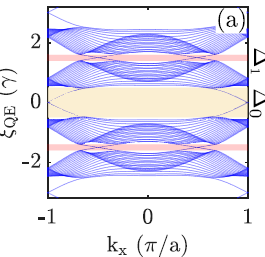

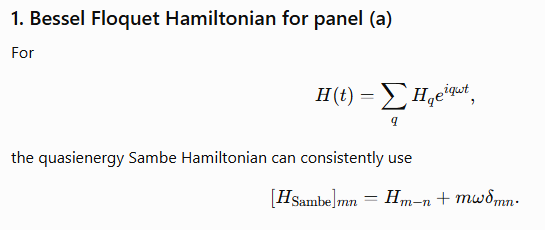

In [21]:
def floquet_bloch_H_bessel(
    k, Ny, gamma=1.0, z=0.5, omega=3.0, Nph=7
):
    """
    Bessel Floquet-Sambe Hamiltonian for an infinite ZGNR.
    Fourier convention:

        H(t) = sum_q H_q exp(+i q omega t)

    Sambe matrix:

        [H_S]_(m,n) = H_(m-n) + m*omega*delta_(m,n)
    """

    n_orb = 2 * Ny
    sectors = np.arange(-Nph, Nph + 1)
    Mmax = 2 * Nph

    H0m, H1m = unit_cell_fourier_bessel(
        Ny=Ny,
        gamma=gamma,
        z=z,
        Mmax=Mmax
    )

    dim = len(sectors) * n_orb
    H_sambe = np.zeros((dim, dim), dtype=complex)

    I_orb = np.eye(n_orb, dtype=complex)

    for a, m in enumerate(sectors):

        row = slice(a * n_orb, (a + 1) * n_orb)

        # Photon-sector energy
        H_sambe[row, row] += m * omega * I_orb

        for b, n in enumerate(sectors):

            col = slice(b * n_orb, (b + 1) * n_orb)
            q = m - n

            # Bloch Fourier component H_q(k)
            Hk_q = (
                H0m[q]
                + H1m[q] * np.exp(1j * k)
                + H1m[-q].conj().T * np.exp(-1j * k)
            )

            H_sambe[row, col] += Hk_q

    return H_sambe

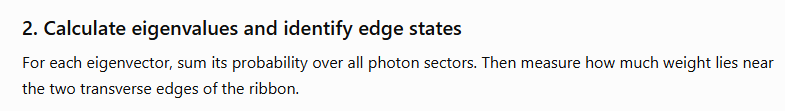

In [22]:
def transverse_edge_weight(eigenvectors, Ny, Nph, edge_rows=3):
    """
    Return the edge weight of every Floquet eigenstate.

    The probability is first summed over all photon sectors,
    giving the physical weight on the 2*Ny graphene orbitals.
    """

    n_orb = 2 * Ny
    n_sectors = 2 * Nph + 1
    n_states = eigenvectors.shape[1]

    # shape: photon sector, graphene orbital, eigenstate
    psi = eigenvectors.reshape(
        n_sectors,
        n_orb,
        n_states
    )

    orbital_probability = np.sum(
        np.abs(psi)**2,
        axis=0
    )

    edge_orbitals = []

    # Bottom edge: first transverse rows
    for j in range(edge_rows):
        edge_orbitals.extend([2*j, 2*j + 1])

    # Top edge: last transverse rows
    for j in range(Ny - edge_rows, Ny):
        edge_orbitals.extend([2*j, 2*j + 1])

    edge_orbitals = np.unique(edge_orbitals)

    return np.sum(
        orbital_probability[edge_orbitals, :],
        axis=0
    )

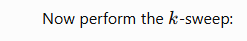

In [23]:
Nph_band = 7
Nk = 150

z = 0.5
omega = 3.0

Emin = -3.0
Emax = 3.0

k_values = np.linspace(
    -np.pi,
    np.pi,
    Nk,
    endpoint=True
)

all_k = []
all_E = []
all_edge_weight = []

for k in k_values:

    H_sambe = floquet_bloch_H_bessel(
        k=k,
        Ny=Ny,
        gamma=gamma,
        z=z,
        omega=omega,
        Nph=Nph_band
    )

    eigvals, eigvecs = np.linalg.eigh(H_sambe)

    keep = (
        (eigvals > Emin)
        & (eigvals < Emax)
    )

    eigvals = eigvals[keep]
    eigvecs = eigvecs[:, keep]

    edge_weight = transverse_edge_weight(
        eigvecs,
        Ny=Ny,
        Nph=Nph_band,
        edge_rows=3
    )

    all_k.append(
        np.full(eigvals.size, k / np.pi)
    )
    all_E.append(eigvals)
    all_edge_weight.append(edge_weight)

k_plot = np.concatenate(all_k)
E_plot = np.concatenate(all_E)
edge_weight_plot = np.concatenate(all_edge_weight)

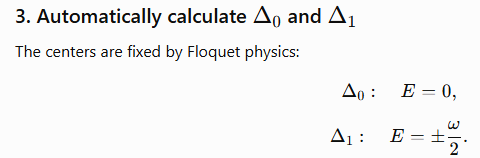

In [24]:
# States below this edge-weight threshold are treated as bulk-like.
# Check stability using, for example, 0.35, 0.40, and 0.45.
edge_threshold = 0.40

bulk_mask = edge_weight_plot < edge_threshold
bulk_energies = E_plot[bulk_mask]


def bulk_gap_around(E_center, bulk_energies):
    """
    Locate the nearest bulk states below and above E_center.
    Their energies define the bulk-gap boundaries.
    """

    below = bulk_energies[bulk_energies < E_center]
    above = bulk_energies[bulk_energies > E_center]

    if len(below) == 0 or len(above) == 0:
        return None

    lower_edge = np.max(below)
    upper_edge = np.min(above)

    if upper_edge <= lower_edge:
        return None

    return lower_edge, upper_edge


gap_Delta0 = bulk_gap_around(
    0.0,
    bulk_energies
)

gap_Delta1_plus = bulk_gap_around(
    +omega / 2,
    bulk_energies
)

gap_Delta1_minus = bulk_gap_around(
    -omega / 2,
    bulk_energies
)

print("Automatically calculated gaps:")

for name, gap in [
    ("Delta_0", gap_Delta0),
    ("Delta_1 (+)", gap_Delta1_plus),
    ("Delta_1 (-)", gap_Delta1_minus)
]:
    if gap is not None:
        lower, upper = gap

        print(
            f"{name}: "
            f"[{lower:+.6f}, {upper:+.6f}], "
            f"width = {upper-lower:.6f}"
        )

Automatically calculated gaps:
Delta_0: [-0.485093, +0.485093], width = 0.970186
Delta_1 (+): [+1.406047, +1.593953], width = 0.187905
Delta_1 (-): [-1.593953, -1.406047], width = 0.187905


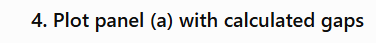

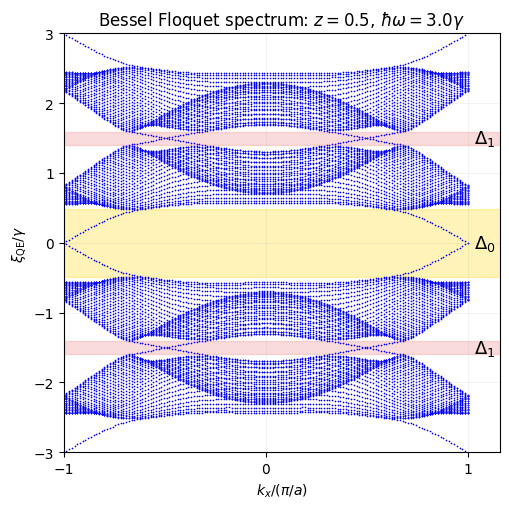

In [25]:
plt.figure(figsize=(5.2, 5.2))

# Plot all quasienergy states
plt.scatter(
    k_plot,
    E_plot,
    s=1.5,
    color="blue",
    linewidths=0
)

detected_gaps = [
    (r"$\Delta_0$", gap_Delta0, "gold"),
    (r"$\Delta_1$", gap_Delta1_plus, "lightcoral"),
    (r"$\Delta_1$", gap_Delta1_minus, "lightcoral")
]

for label, gap, color in detected_gaps:

    if gap is None:
        continue

    lower, upper = gap

    plt.axhspan(
        lower,
        upper,
        color=color,
        alpha=0.28,
        zorder=0
    )

    plt.text(
        1.03,
        0.5 * (lower + upper),
        label,
        fontsize=13,
        va="center"
    )

plt.xlabel(r"$k_x/(\pi/a)$")
plt.ylabel(r"$\xi_{\rm QE}/\gamma$")

plt.xlim(-1.0, 1.16)
plt.ylim(-3.0, 3.0)

plt.xticks([-1, 0, 1])
plt.grid(alpha=0.15)

plt.title(
    rf"Bessel Floquet spectrum: "
    rf"$z={z}$, $\hbar\omega={omega}\gamma$"
)

plt.tight_layout()
plt.show()

The reported gap boundaries should be tested for stability against Nk, edge_rows, and edge_threshold. If the boundaries move strongly when changing edge_threshold from 0.35 to 0.45, the bulk/edge classification needs refinement

In [26]:
threshold_values = [0.30, 0.35, 0.40, 0.45, 0.50]

print(
    f"{'threshold':>10} | "
    f"{'Delta0 lower':>12} {'Delta0 upper':>12} {'width':>10} | "
    f"{'Delta1 lower':>12} {'Delta1 upper':>12} {'width':>10}"
)

print("-" * 92)

for threshold in threshold_values:

    bulk_mask_test = edge_weight_plot < threshold
    bulk_E_test = E_plot[bulk_mask_test]

    gap0 = bulk_gap_around(
        0.0,
        bulk_E_test
    )

    gap1 = bulk_gap_around(
        omega / 2,
        bulk_E_test
    )

    if gap0 is not None and gap1 is not None:

        g0_lower, g0_upper = gap0
        g1_lower, g1_upper = gap1

        print(
            f"{threshold:10.2f} | "
            f"{g0_lower:12.5f} {g0_upper:12.5f} "
            f"{g0_upper-g0_lower:10.5f} | "
            f"{g1_lower:12.5f} {g1_upper:12.5f} "
            f"{g1_upper-g1_lower:10.5f}"
        )

 threshold | Delta0 lower Delta0 upper      width | Delta1 lower Delta1 upper      width
--------------------------------------------------------------------------------------------
      0.30 |     -0.48509      0.48509    0.97019 |      1.39301      1.60699    0.21399
      0.35 |     -0.48509      0.48509    0.97019 |      1.40134      1.59866    0.19731
      0.40 |     -0.48509      0.48509    0.97019 |      1.40605      1.59395    0.18791
      0.45 |     -0.48068      0.48068    0.96137 |      1.41269      1.58731    0.17462
      0.50 |     -0.48068      0.48068    0.96137 |      1.41920      1.58080    0.16159


## Part C — Graphene Floquet scattering matrices

### Cell C1: Hermitian matrix square root

In [21]:
# ============================================================
# PART C — FLOQUET SCATTERING MATRICES
# Cell C1: Hermitian matrix square root
# ============================================================

def hermitian_matrix_sqrt(matrix, eigenvalue_tol=1e-10):
    """
    Compute the positive-semidefinite square root
    of a Hermitian Gamma matrix.
    """

    matrix_H = 0.5 * (
        matrix + matrix.conj().T
    )

    eigenvalues, eigenvectors = np.linalg.eigh(matrix_H)

    scale = max(
        np.max(np.abs(eigenvalues)),
        1.0
    )

    cutoff = eigenvalue_tol * scale

    # Keep positive eigenvalues and remove tiny numerical negatives
    eigenvalues_clipped = np.where(
        eigenvalues > cutoff,
        eigenvalues,
        0.0
    )

    sqrt_matrix = (
        eigenvectors
        @ np.diag(np.sqrt(eigenvalues_clipped))
        @ eigenvectors.conj().T
    )

    return sqrt_matrix

### Cell C2: Static ZGNR contact Sigma and Gamma matrices

In [22]:
# ============================================================
# Cell C2: Static ZGNR contact Sigma and Gamma matrices
# ============================================================

def graphene_contact_matrices(
    energy,
    H00,
    H01,
    eta=1e-6
):
    """
    Compute contact self-energies and broadenings for the
    left and right static ZGNR leads at one energy.

    Returns
    -------
    contacts : dict
        SigmaL, SigmaR, GammaL, GammaR,
        sqrtGammaL, sqrtGammaR.
    """

    # Right-facing semi-infinite lead
    g_surface_R = sancho_surface_gf(
        E=energy,
        H00=H00,
        H01=H01,
        eta=eta
    )

    # Left-facing semi-infinite lead
    g_surface_L = sancho_surface_gf(
        E=energy,
        H00=H00,
        H01=H01.conj().T,
        eta=eta
    )

    SigmaR = (
        H01
        @ g_surface_R
        @ H01.conj().T
    )

    SigmaL = (
        H01.conj().T
        @ g_surface_L
        @ H01
    )

    GammaL = 1j * (
        SigmaL - SigmaL.conj().T
    )

    GammaR = 1j * (
        SigmaR - SigmaR.conj().T
    )

    sqrtGammaL = hermitian_matrix_sqrt(GammaL)
     

    sqrtGammaR = hermitian_matrix_sqrt(GammaR)
       
    

    return {
        "SigmaL": SigmaL,
        "SigmaR": SigmaR,
        "GammaL": GammaL,
        "GammaR": GammaR,
        "sqrtGammaL": sqrtGammaL,
        "sqrtGammaR": sqrtGammaR,
        
    }

### Cell C3: Selected contact columns of the Floquet Green function

In [23]:
# ============================================================
# Cell C3: Selected contact columns of the Floquet Green function
#solve only for columns corresponding to the left and right contacts of the incoming m=0 sector
# ============================================================

def graphene_contact_green_blocks(
    E,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    eta=1e-6
):
    """
    Compute only the Green-function columns needed for scattering:

        G^r_pp'(E_m, E)

    where the incoming electron is in Floquet sector 0 and
    the outgoing electron is in sector m.

    Returns
    -------
    G_by_m : dict
        G_by_m[m]["LL"], ["LR"], ["RL"], ["RR"],
        each of shape (N_orb, N_orb).

    SigmaL_F, SigmaR_F : ndarray
        Full Floquet lead self-energy matrices.
    """

    sectors = np.arange(-Nph, Nph + 1)

    n_orb = H00.shape[0]
    n_device = Nx * n_orb
    n_floquet = len(sectors) * n_device

    # Floquet self-energies at base energy E
    SigmaL_F, SigmaR_F = graphene_floquet_self_energies(
        E=E,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    identity_F = np.eye(
        n_floquet,
        dtype=complex
    )

    A_matrix = (
        (E + 1j * eta) * identity_F
        + OmegaF
        - HF
        - SigmaL_F
        - SigmaR_F
    )

    # --------------------------------------------------------
    # Incoming sector is m = 0
    # --------------------------------------------------------

    a0 = np.where(sectors == 0)[0][0]
    sector0_offset = a0 * n_device

    incoming_left = np.arange(
        sector0_offset,
        sector0_offset + n_orb
    )

    incoming_right = np.arange(
        sector0_offset + (Nx - 1) * n_orb,
        sector0_offset + Nx * n_orb
    )

    # P selects only incoming L and R interface columns
    P_contacts = np.zeros(
        (n_floquet, 2 * n_orb),
        dtype=complex
    )

    P_contacts[incoming_left, :n_orb] = np.eye(
        n_orb,
        dtype=complex
    )

    P_contacts[incoming_right, n_orb:] = np.eye(
        n_orb,
        dtype=complex
    )

    # Solve:
    #
    # A X = P
    #
    # Therefore:
    #
    # X = G^r P
    #
    # X contains only the required contact columns.
    X = np.linalg.solve(
        A_matrix,
        P_contacts
    )

    G_by_m = {}

    for a, m in enumerate(sectors):

        sector_offset = a * n_device

        outgoing_left = slice(
            sector_offset,
            sector_offset + n_orb
        )

        outgoing_right = slice(
            sector_offset + (Nx - 1) * n_orb,
            sector_offset + Nx * n_orb
        )

        # First n_orb columns correspond to incoming L.
        # Last n_orb columns correspond to incoming R.
        GLL = X[outgoing_left, :n_orb]
        GLR = X[outgoing_left, n_orb:]

        GRL = X[outgoing_right, :n_orb]
        GRR = X[outgoing_right, n_orb:]

        G_by_m[int(m)] = {
            "LL": GLL,
            "LR": GLR,
            "RL": GRL,
            "RR": GRR
        }

    return G_by_m, SigmaL_F, SigmaR_F

### Cell C4: Fisher-Lee Floquet scattering matrices

In [24]:
# ============================================================
# Cell C4: Fisher-Lee Floquet scattering matrices
#Construct graphene Floquet scattering matrices
# ============================================================

def build_graphene_scattering_matrices(
    G_by_m,
    E,
    H00,
    H01,
    omega,
    eta=1e-6
):
    """
    Construct

        S_pp'(E_m, E)

    for every outgoing Floquet sector m using the
    generalized Fisher-Lee relation.

    Returns
    -------
    S_by_m : dict
        S_by_m[m]["LL"], ["LR"], ["RL"], ["RR"].
    """

    n_orb = H00.shape[0]
    identity_contact = np.eye(
        n_orb,
        dtype=complex
    )

    # Incoming broadenings at energy E
    incoming = graphene_contact_matrices(
        energy=E,
        H00=H00,
        H01=H01,
        eta=eta
    )

    sqrtGammaL_in = incoming["sqrtGammaL"]
    sqrtGammaR_in = incoming["sqrtGammaR"]

    S_by_m = {}

    for m, Gcontact in G_by_m.items():

        Em = E + m * omega

        # Outgoing broadenings at energy E_m
        outgoing = graphene_contact_matrices(
            energy=Em,
            H00=H00,
            H01=H01,
            eta=eta
        )

        sqrtGammaL_out = outgoing["sqrtGammaL"]
        sqrtGammaR_out = outgoing["sqrtGammaR"]

        delta_m0 = 1.0 if m == 0 else 0.0

        SLL = (
            delta_m0 * identity_contact
            - 1j
            * sqrtGammaL_out
            @ Gcontact["LL"]
            @ sqrtGammaL_in
        )

        SLR = (
            -1j
            * sqrtGammaL_out
            @ Gcontact["LR"]
            @ sqrtGammaR_in
        )

        SRL = (
            -1j
            * sqrtGammaR_out
            @ Gcontact["RL"]
            @ sqrtGammaL_in
        )

        SRR = (
            delta_m0 * identity_contact
            - 1j
            * sqrtGammaR_out
            @ Gcontact["RR"]
            @ sqrtGammaR_in
        )

        S_by_m[m] = {
            "LL": SLL,
            "LR": SLR,
            "RL": SRL,
            "RR": SRR
        }

    return S_by_m, incoming

### Cell C5: Build contact Green functions and scattering matrices

In [23]:
expected_dim = (2 * Nph + 1) * Nx * N_orb

print("HF shape       =", HF.shape)
print("OmegaF shape   =", OmegaF.shape)
print("Expected shape =", (expected_dim, expected_dim))

HF shape       = (15660, 15660)
OmegaF shape   = (15660, 15660)
Expected shape = (15660, 15660)


In [24]:
# ============================================================
# Cell C5: Build contact Green functions and scattering matrices
# at one test energy
# ============================================================

E_test = 0.0

Gcontact_by_m, SigmaL_test, SigmaR_test = (
    graphene_contact_green_blocks(
        E=E_test,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta_floquet
    )
)

S_by_m_test, incoming_contacts_test = (
    build_graphene_scattering_matrices(
        G_by_m=Gcontact_by_m,
        E=E_test,
        H00=H00,
        H01=H01,
        omega=omega,
        eta=eta_floquet
    )
)

for m in sorted(S_by_m_test):

    print(f"\nFloquet sector m = {m}")

    for key in ["LL", "LR", "RL", "RR"]:

        print(
            key,
            S_by_m_test[m][key].shape,
            "norm =",
            np.linalg.norm(
                S_by_m_test[m][key],
                ord="fro"
            )
        )


Floquet sector m = -4
LL (58, 58) norm = 2.4360896876508644e-07
LR (58, 58) norm = 1.8437613905972295e-07
RL (58, 58) norm = 1.843761391601901e-07
RR (58, 58) norm = 2.436089686653254e-07

Floquet sector m = -3
LL (58, 58) norm = 2.100510996347347e-06
LR (58, 58) norm = 2.6470003540974554e-06
RL (58, 58) norm = 2.647000355567126e-06
RR (58, 58) norm = 2.100510995074553e-06

Floquet sector m = -2
LL (58, 58) norm = 2.2187983566469762e-05
LR (58, 58) norm = 2.017243538104248e-05
RL (58, 58) norm = 2.0172435392089873e-05
RR (58, 58) norm = 2.2187983558263165e-05

Floquet sector m = -1
LL (58, 58) norm = 0.0005372488044859413
LR (58, 58) norm = 0.000839910419238507
RL (58, 58) norm = 0.0008399104197110619
RR (58, 58) norm = 0.0005372488040079933

Floquet sector m = 0
LL (58, 58) norm = 7.559102716640065
LR (58, 58) norm = 0.9272349067923296
RL (58, 58) norm = 0.927234907271005
RR (58, 58) norm = 7.559102716596684

Floquet sector m = 1
LL (58, 58) norm = 0.0005372488042682212
LR (58, 58) n

In [25]:
print("Nph used in C5 =", Nph)
print("HF shape       =", HF.shape)
print("Scattering sectors =", sorted(S_by_m_test.keys()))
print("Number of sectors  =", len(S_by_m_test))

Nph used in C5 = 4
HF shape       = (15660, 15660)
Scattering sectors = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
Number of sectors  = 9


### Cell C6: Floquet scattering-matrix unitarity

In [26]:
# ============================================================
# Cell C6: Floquet scattering-matrix unitarity
# Directly in the graphene contact-orbital space
# ============================================================

def check_graphene_floquet_unitarity(S_by_m):
    """
    Check the Floquet scattering-matrix unitarity relations

        sum_m [S_LL^dagger(m) S_LL(m)
             + S_RL^dagger(m) S_RL(m)] = I

    for electrons incident from the left lead, and

        sum_m [S_LR^dagger(m) S_LR(m)
             + S_RR^dagger(m) S_RR(m)] = I

    for electrons incident from the right lead.

    All matrices act in the graphene contact-orbital space.
    """

    first_sector = next(iter(S_by_m.values()))
    n_contact = first_sector["LL"].shape[0]

    U_in_L = np.zeros(
        (n_contact, n_contact),
        dtype=complex
    )

    U_in_R = np.zeros(
        (n_contact, n_contact),
        dtype=complex
    )

    for m in sorted(S_by_m):

        S = S_by_m[m]

        # Electron incident from the left lead:
        # it can exit into either L or R
        U_in_L += (
            S["LL"].conj().T @ S["LL"]
            + S["RL"].conj().T @ S["RL"]
        )

        # Electron incident from the right lead:
        # it can exit into either L or R
        U_in_R += (
            S["LR"].conj().T @ S["LR"]
            + S["RR"].conj().T @ S["RR"]
        )

    I_contact = np.eye(
        n_contact,
        dtype=complex
    )

    error_L = np.linalg.norm(
        U_in_L - I_contact,
        ord="fro"
    )

    error_R = np.linalg.norm(
        U_in_R - I_contact,
        ord="fro"
    )

    max_error_L = np.max(
        np.abs(U_in_L - I_contact)
    )

    max_error_R = np.max(
        np.abs(U_in_R - I_contact)
    )

    print("Contact-space dimension =", n_contact)

    print(
        "Frobenius unitarity error, incidence from L =",
        error_L
    )

    print(
        "Frobenius unitarity error, incidence from R =",
        error_R
    )

    print(
        "Maximum elementwise error, incidence from L =",
        max_error_L
    )

    print(
        "Maximum elementwise error, incidence from R =",
        max_error_R
    )

    return {
        "U_in_L": U_in_L,
        "U_in_R": U_in_R,
        "error_L": error_L,
        "error_R": error_R,
        "max_error_L": max_error_L,
        "max_error_R": max_error_R
    }

#### unitarity_check

In [27]:
unitarity_results = check_graphene_floquet_unitarity(
    S_by_m=S_by_m_test
)

Contact-space dimension = 58
Frobenius unitarity error, incidence from L = 0.0001950923509534729
Frobenius unitarity error, incidence from R = 0.00019509383449710585
Maximum elementwise error, incidence from L = 4.0867657964738235e-05
Maximum elementwise error, incidence from R = 4.0867906706876234e-05


## PART D — N=0 CURRENT FROM BESSEL FLOQUET SCATTERING

### Cell D1: Reuse the Bessel Floquet matrices from Part B

In [28]:
# ============================================================
# Cell D1: Reuse the Bessel Floquet matrices from Part B
#
# HF and OmegaF were already constructed in B5 from the
# analytic Bessel Fourier components produced in B4.
# No Floquet Hamiltonian is rebuilt here.
# ============================================================

Nph_N0 = Nph
HF_N0 = HF
OmegaF_N0 = OmegaF

expected_dimension_N0 = (
    (2 * Nph_N0 + 1)
    * Nx
    * N_orb
)

print("Reusing Bessel Floquet matrices from Part B")
print("--------------------------------------------")
print("Nph                =", Nph_N0)
print("HF_N0 shape        =", HF_N0.shape)
print("OmegaF_N0 shape    =", OmegaF_N0.shape)
print(
    "Expected shape     =",
    (expected_dimension_N0, expected_dimension_N0)
)
print(
    "Hermiticity error  =",
    np.linalg.norm(
        HF_N0 - HF_N0.conj().T
    )
)

Reusing Bessel Floquet matrices from Part B
--------------------------------------------
Nph                = 4
HF_N0 shape        = (15660, 15660)
OmegaF_N0 shape    = (15660, 15660)
Expected shape     = (15660, 15660)
Hermiticity error  = 0.0


### Cell D2: Parameters for the N=0 current calculation

In [29]:
# ============================================================
# Cell D2: Parameters for the N=0 current
#
# Zero bias at the Floquet-zone edge:
#
#     EF = hbar*omega/2
#     muL = muR = EF
# ============================================================

EF_N0 = omega / 2

muL_N0 = EF_N0
muR_N0 = EF_N0

# Static graphene lead band is approximately [-3, +3].
# At T=0, occupied states extend from the band bottom to EF.
Emin_N0 = -3.0
Emax_N0 = EF_N0

NE_N0 = 80

E_grid_N0 = np.linspace(
    Emin_N0,
    Emax_N0,
    NE_N0
)

gamma_eV = 2.7
EV_OVER_H_TO_UA = 38.74
spin_degeneracy = 2

print("N=0 calculation parameters")
print("--------------------------")
print("EF  =", EF_N0)
print("muL =", muL_N0)
print("muR =", muR_N0)
print("Vb  =", muL_N0 - muR_N0)
print("Nph =", Nph_N0)
print("NE  =", NE_N0)
print("Energy range =", (Emin_N0, Emax_N0))
print("eta =", eta_floquet)

N=0 calculation parameters
--------------------------
EF  = 1.5
muL = 1.5
muR = 1.5
Vb  = 0.0
Nph = 4
NE  = 80
Energy range = (-3.0, 1.5)
eta = 1e-06


### Cell D3: Zero-temperature reservoir occupation

In [30]:
# ============================================================
# Cell D3: Zero-temperature reservoir occupation
#
# At T=0:
#
#     f_p(E) = 1,    E < mu_p
#            = 1/2,  E = mu_p
#            = 0,    E > mu_p
#
# Here, at zero bias:
#
#     muL = muR = EF = hbar*omega/2 = 1.5 gamma
# ============================================================

def reservoir_occupation_N0(E, mu):
    if E < mu:
        return 1.0

    if E > mu:
        return 0.0

    # The value at the single point E=mu does not affect
    # the continuous energy integral.
    return 0.5


# Quick check
print("Occupation check at zero temperature")
print("------------------------------------")

print(
    "fL(Emin) =",
    reservoir_occupation_N0(
        E=Emin_N0,
        mu=muL_N0
    )
)

print(
    "fL(EF)   =",
    reservoir_occupation_N0(
        E=EF_N0,
        mu=muL_N0
    )
)

print(
    "fR(EF)   =",
    reservoir_occupation_N0(
        E=EF_N0,
        mu=muR_N0
    )
)

print(
    "fL(EF+0.1) =",
    reservoir_occupation_N0(
        E=EF_N0 + 0.1,
        mu=muL_N0
    )
)

Occupation check at zero temperature
------------------------------------
fL(Emin) = 1.0
fL(EF)   = 0.5
fR(EF)   = 0.5
fL(EF+0.1) = 0.0


### Cell D4: N=0 current integrand at one energy

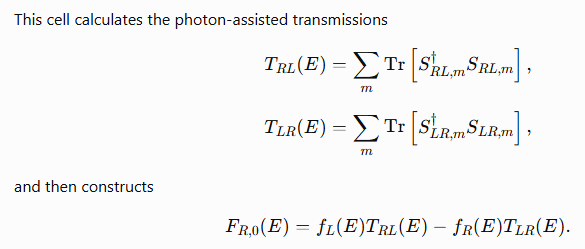

In [31]:
# ============================================================
# Cell D4: N=0 current integrand at one incoming energy
#
# The Bessel dependence is already contained in HF_N0:
#
#   Bessel J_q(2z) -> H_q -> HF_N0 -> G^r -> S -> I_p,0
#
# No Hamiltonian or Fourier component is rebuilt here.
# ============================================================

def graphene_N0_bessel_integrand_at_energy(
    E,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    muL,
    muR,
    eta=1e-6
):
    # Incoming reservoir occupations
    fL = reservoir_occupation_N0(
        E=E,
        mu=muL
    )

    fR = reservoir_occupation_N0(
        E=E,
        mu=muR
    )

    # No occupied incoming states above both chemical potentials.
    if fL == 0.0 and fR == 0.0:
        diagnostics = {
            "T_RL": 0.0,
            "T_LR": 0.0,
            "delta_T": 0.0
        }

        return 0.0, 0.0, diagnostics

    # Contact Green-function blocks:
    #
    #     G^r_pp'(E+m*omega, E)
    #
    # HF is the Bessel-based Floquet Hamiltonian from Part B.
    G_by_m, _, _ = graphene_contact_green_blocks(
        E=E,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    # Generalized Fisher-Lee relation:
    #
    #     G^r -> S_pp',m
    S_by_m, _ = build_graphene_scattering_matrices(
        G_by_m=G_by_m,
        E=E,
        H00=H00,
        H01=H01,
        omega=omega,
        eta=eta
    )

    T_RL = 0.0
    T_LR = 0.0

    for m in sorted(S_by_m):

        S = S_by_m[m]

        # Incoming from L, outgoing through R
        T_RL += np.trace(
            S["RL"].conj().T
            @ S["RL"]
        ).real

        # Incoming from R, outgoing through L
        T_LR += np.trace(
            S["LR"].conj().T
            @ S["LR"]
        ).real

    # Current flowing into the right lead
    F_R0 = (
        fL * T_RL
        - fR * T_LR
    )

    # Current flowing into the left lead
    F_L0 = (
        fR * T_LR
        - fL * T_RL
    )

    diagnostics = {
        "T_RL": T_RL,
        "T_LR": T_LR,
        "delta_T": T_RL - T_LR
    }

    return F_R0, F_L0, diagnostics


print(
    "Cell D4 loaded: "
    "graphene_N0_bessel_integrand_at_energy is ready."
)

Cell D4 loaded: graphene_N0_bessel_integrand_at_energy is ready.


### Cell D5: Evaluate the N=0 integrand over energy

In [32]:
# ============================================================
# Cell D5: Evaluate the N=0 current integrand over energy
# ============================================================

integrand_R0 = np.zeros(
    NE_N0,
    dtype=float
)

integrand_L0 = np.zeros(
    NE_N0,
    dtype=float
)

T_RL_grid = np.zeros(
    NE_N0,
    dtype=float
)

T_LR_grid = np.zeros(
    NE_N0,
    dtype=float
)

delta_T_grid = np.zeros(
    NE_N0,
    dtype=float
)

for iE, E in enumerate(E_grid_N0):

    F_R0, F_L0, diagnostics = (
        graphene_N0_bessel_integrand_at_energy(
            E=E,

            # Reuse the Bessel Floquet matrices from Part B
            HF=HF_N0,
            OmegaF=OmegaF_N0,

            H00=H00,
            H01=H01,
            Nx=Nx,
            Nph=Nph_N0,
            omega=omega,

            muL=muL_N0,
            muR=muR_N0,

            eta=eta_floquet
        )
    )

    integrand_R0[iE] = F_R0
    integrand_L0[iE] = F_L0

    T_RL_grid[iE] = diagnostics["T_RL"]
    T_LR_grid[iE] = diagnostics["T_LR"]
    delta_T_grid[iE] = diagnostics["delta_T"]

    if (
        iE == 0
        or (iE + 1) % 10 == 0
        or iE == NE_N0 - 1
    ):
        print(
            f"Energy {iE+1:4d}/{NE_N0}: "
            f"E={E:+.6f}, "
            f"T_RL-T_LR="
            f"{diagnostics['delta_T']:+.3e}"
        )

Energy    1/80: E=-3.000000, T_RL-T_LR=-2.163e-17
Energy   10/80: E=-2.487342, T_RL-T_LR=+8.937e-15
Energy   20/80: E=-1.917722, T_RL-T_LR=+4.739e-12
Energy   30/80: E=-1.348101, T_RL-T_LR=+6.786e-13
Energy   40/80: E=-0.778481, T_RL-T_LR=-1.360e-11
Energy   50/80: E=-0.208861, T_RL-T_LR=-6.165e-12
Energy   60/80: E=+0.360759, T_RL-T_LR=+2.621e-12
Energy   70/80: E=+0.930380, T_RL-T_LR=-5.908e-12
Energy   80/80: E=+1.500000, T_RL-T_LR=+7.661e-14


### Cell D6: Integrate and obtain IL,0 and IR,0

In [33]:
# ============================================================
# Cell D6: Integrate the N=0 current and convert to microamperes
#
# Natural current units:
#
#     e*gamma/h
#
# Physical conversion:
#
#     (e/h)(1 eV) = 38.74 microampere
#
# The factor spin_degeneracy=2 accounts for graphene spin.
# ============================================================

trapz_N0 = (
    np.trapezoid
    if hasattr(np, "trapezoid")
    else np.trapz
)

# Energy integration in natural units e*gamma/h
I_R0_natural = (
    spin_degeneracy
    * trapz_N0(
        integrand_R0,
        E_grid_N0
    )
)

I_L0_natural = (
    spin_degeneracy
    * trapz_N0(
        integrand_L0,
        E_grid_N0
    )
)

# Convert from e*gamma/h to microamperes
I_R0_microamp = (
    EV_OVER_H_TO_UA
    * gamma_eV
    * I_R0_natural
)

I_L0_microamp = (
    EV_OVER_H_TO_UA
    * gamma_eV
    * I_L0_natural
)

print("\n" + "=" * 72)
print("N=0 current from the Bessel-Floquet scattering calculation")
print("=" * 72)

print("\nCalculation parameters")
print("----------------------")
print("EF   =", EF_N0)
print("muL  =", muL_N0)
print("muR  =", muR_N0)
print("Vb   =", muL_N0 - muR_N0)
print("Nph  =", Nph_N0)
print("NE   =", NE_N0)

print("\nNatural units: e*gamma/h")
print(
    f"I_R,0 = {I_R0_natural:+.12e}"
)
print(
    f"I_L,0 = {I_L0_natural:+.12e}"
)

print("\nPhysical units")
print(
    f"I_R,0 = {I_R0_microamp:+.12e} microampere"
)
print(
    f"I_L,0 = {I_L0_microamp:+.12e} microampere"
)

print("\nDC conservation check")
print(
    f"I_L,0 + I_R,0 = "
    f"{I_L0_microamp + I_R0_microamp:+.12e} "
    "microampere"
)


N=0 current from the Bessel-Floquet scattering calculation

Calculation parameters
----------------------
EF   = 1.5
muL  = 1.5
muR  = 1.5
Vb   = 0.0
Nph  = 4
NE   = 80

Natural units: e*gamma/h
I_R,0 = +2.886630444321e-09
I_L,0 = -2.886630444321e-09

Physical units
I_R,0 = +3.019357712151e-07 microampere
I_L,0 = -3.019357712151e-07 microampere

DC conservation check
I_L,0 + I_R,0 = +0.000000000000e+00 microampere


### Cell D8: Plot the N=0 energy-resolved results

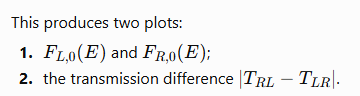

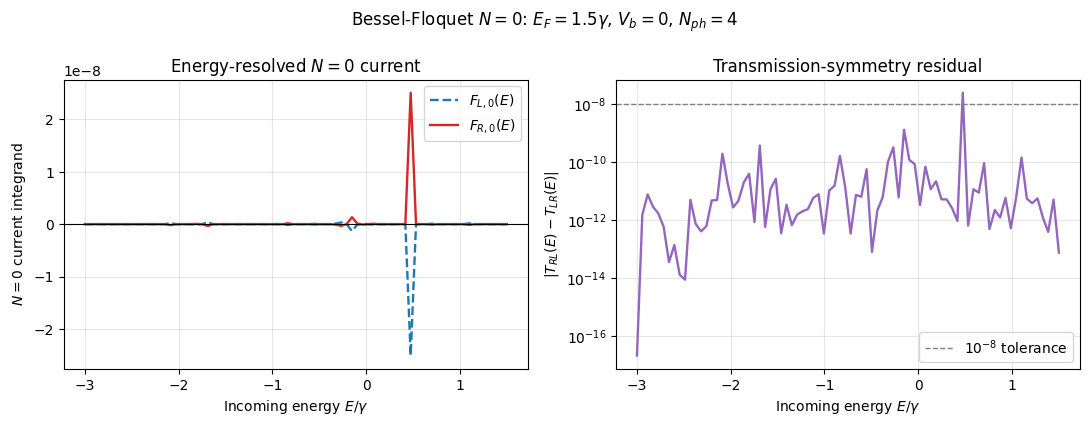

In [34]:
# ============================================================
# Cell D8: Energy-resolved N=0 plots
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.3)
)

# ------------------------------------------------------------
# Panel 1: N=0 current integrands
# ------------------------------------------------------------

axes[0].plot(
    E_grid_N0,
    integrand_L0,
    linestyle="--",
    linewidth=1.7,
    color="tab:blue",
    label=r"$F_{L,0}(E)$"
)

axes[0].plot(
    E_grid_N0,
    integrand_R0,
    linestyle="-",
    linewidth=1.7,
    color="tab:red",
    label=r"$F_{R,0}(E)$"
)

axes[0].axhline(
    0.0,
    color="black",
    linewidth=0.8
)

axes[0].set_xlabel(
    r"Incoming energy $E/\gamma$"
)

axes[0].set_ylabel(
    r"$N=0$ current integrand"
)

axes[0].set_title(
    r"Energy-resolved $N=0$ current"
)

axes[0].grid(
    alpha=0.3
)

axes[0].legend()

# ------------------------------------------------------------
# Panel 2: Left-right transmission difference
# ------------------------------------------------------------

axes[1].semilogy(
    E_grid_N0,
    np.maximum(
        np.abs(delta_T_grid),
        1e-30
    ),
    color="tab:purple",
    linewidth=1.7
)

axes[1].axhline(
    1e-8,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label=r"$10^{-8}$ tolerance"
)

axes[1].set_xlabel(
    r"Incoming energy $E/\gamma$"
)

axes[1].set_ylabel(
    r"$|T_{RL}(E)-T_{LR}(E)|$"
)

axes[1].set_title(
    "Transmission-symmetry residual"
)

axes[1].grid(
    alpha=0.3
)

axes[1].legend()

fig.suptitle(
    rf"Bessel-Floquet $N=0$: "
    rf"$E_F={EF_N0}\gamma$, "
    rf"$V_b=0$, "
    rf"$N_{{ph}}={Nph_N0}$",
    fontsize=12
)

plt.tight_layout()
plt.show()

### Cell D9: Plot the final integrated N=0 currents

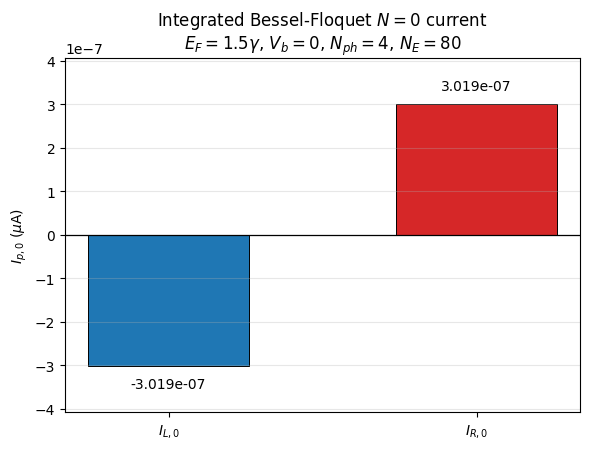

In [35]:
# ============================================================
# Cell D9: Final integrated N=0 current plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.0, 4.6)
)

lead_labels = [
    r"$I_{L,0}$",
    r"$I_{R,0}$"
]

current_values = np.array([
    I_L0_microamp,
    I_R0_microamp
])

bars = ax.bar(
    lead_labels,
    current_values,
    color=[
        "tab:blue",
        "tab:red"
    ],
    width=0.52,
    edgecolor="black",
    linewidth=0.7
)

ax.axhline(
    0.0,
    color="black",
    linewidth=0.9
)

ax.set_ylabel(
    r"$I_{p,0}$ ($\mu$A)"
)

ax.set_title(
    rf"Integrated Bessel-Floquet $N=0$ current"
    "\n"
    rf"$E_F={EF_N0}\gamma$, "
    rf"$V_b=0$, "
    rf"$N_{{ph}}={Nph_N0}$, "
    rf"$N_E={NE_N0}$"
)

ax.grid(
    axis="y",
    alpha=0.3
)

# Add numerical values above/below the bars
offset = max(
    np.max(np.abs(current_values)) * 0.08,
    1e-12
)

for bar, value in zip(bars, current_values):

    if value >= 0:
        vertical_alignment = "bottom"
        y_text = value + offset
    else:
        vertical_alignment = "top"
        y_text = value - offset

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_text,
        f"{value:.3e}",
        ha="center",
        va=vertical_alignment,
        fontsize=10
    )

# Symmetric vertical axis
current_scale = max(
    np.max(np.abs(current_values)),
    1e-12
)

ax.set_ylim(
    -1.35 * current_scale,
    1.35 * current_scale
)

plt.tight_layout()
plt.show()

### Cell D10: Nph convergence check, following the exact criterion

In [ ]:
# ============================================================
# Cell D10: Nph convergence test for the N=0 current
#
# At zero bias, the physical result for this symmetric junction is
#
#     I_R,0 = I_L,0 = 0.
#
# Therefore, convergence is tested using the absolute residual
#
#     |I_R,0(Nph)|
#
# rather than a relative percentage whose denominator is nearly zero.
#
# This cell:
#   1. calculates Nph = 1, 2, 3;
#   2. reuses the Nph = 4 result already obtained in D6;
#   3. uses exactly the same energy grid and physical parameters
#      for every Nph.
# ============================================================

import time


def compute_N0_convergence_point(Nph_test):
    """
    Calculate I_R,0 and transmission-symmetry diagnostics for one
    Floquet truncation Nph_test.
    """

    print("\n" + "=" * 72)
    print(f"Starting Nph = {Nph_test}")
    print("=" * 72)

    start_time = time.time()

    # Construct the Floquet matrices for this truncation using the
    # Bessel Fourier components already calculated in Part B.
    HF_test, OmegaF_test = assemble_floquet_matrices(
        H_fourier=H_fourier,
        Nph=Nph_test,
        omega=omega
    )

    expected_dimension = (
        (2 * Nph_test + 1)
        * Nx
        * N_orb
    )

    print("Floquet matrix shape =", HF_test.shape)
    print(
        "Expected shape       =",
        (expected_dimension, expected_dimension)
    )

    integrand_R0_test = np.zeros(
        NE_N0,
        dtype=float
    )

    delta_T_test = np.zeros(
        NE_N0,
        dtype=float
    )

    for iE, E in enumerate(E_grid_N0):

        F_R0, _, diagnostics = (
            graphene_N0_bessel_integrand_at_energy(
                E=E,
                HF=HF_test,
                OmegaF=OmegaF_test,
                H00=H00,
                H01=H01,
                Nx=Nx,
                Nph=Nph_test,
                omega=omega,
                muL=muL_N0,
                muR=muR_N0,
                eta=eta_floquet
            )
        )

        integrand_R0_test[iE] = F_R0
        delta_T_test[iE] = diagnostics["delta_T"]

        # Progress report every ten energy points
        if (
            iE == 0
            or (iE + 1) % 10 == 0
            or iE == NE_N0 - 1
        ):
            elapsed_minutes = (
                time.time() - start_time
            ) / 60.0

            print(
                f"Nph={Nph_test}, "
                f"energy {iE+1:3d}/{NE_N0}, "
                f"E={E:+.6f}, "
                f"|T_RL-T_LR|="
                f"{abs(delta_T_test[iE]):.3e}, "
                f"elapsed={elapsed_minutes:.1f} min"
            )

    # Integrate in natural units e*gamma/h
    I_R0_natural_test = (
        spin_degeneracy
        * trapz_N0(
            integrand_R0_test,
            E_grid_N0
        )
    )

    # Convert to microamperes
    I_R0_microamp_test = (
        EV_OVER_H_TO_UA
        * gamma_eV
        * I_R0_natural_test
    )

    max_delta_T_test = np.max(
        np.abs(delta_T_test)
    )

    integrated_abs_delta_T_test = trapz_N0(
        np.abs(delta_T_test),
        E_grid_N0
    )

    total_minutes = (
        time.time() - start_time
    ) / 60.0

    print("\nCompleted result")
    print("----------------")
    print(
        f"Nph                    = {Nph_test}"
    )
    print(
        f"I_R,0                   = "
        f"{I_R0_microamp_test:+.12e} microampere"
    )
    print(
        f"|I_R,0|                 = "
        f"{abs(I_R0_microamp_test):.12e} microampere"
    )
    print(
        f"max_E |T_RL-T_LR|       = "
        f"{max_delta_T_test:.12e}"
    )
    print(
        f"integral |T_RL-T_LR| dE = "
        f"{integrated_abs_delta_T_test:.12e}"
    )
    print(
        f"Elapsed time             = "
        f"{total_minutes:.1f} minutes"
    )

    return {
        "I_R0_microamp": I_R0_microamp_test,
        "max_delta_T": max_delta_T_test,
        "integrated_abs_delta_T": integrated_abs_delta_T_test
    }


# ------------------------------------------------------------
# Calculate Nph = 1, 2, 3
# ------------------------------------------------------------

N0_convergence_results = {}

for Nph_test in [1, 2, 3]:

    N0_convergence_results[Nph_test] = (
        compute_N0_convergence_point(
            Nph_test=Nph_test
        )
    )


# ------------------------------------------------------------
# Reuse the Nph = 4 result already calculated in D5-D6
#
# delta_T_grid is also the Nph=4 transmission residual from D5.
# ------------------------------------------------------------

N0_convergence_results[4] = {
    "I_R0_microamp": float(I_R0_microamp),

    "max_delta_T": float(
        np.max(
            np.abs(delta_T_grid)
        )
    ),

    "integrated_abs_delta_T": float(
        trapz_N0(
            np.abs(delta_T_grid),
            E_grid_N0
        )
    )
}


# ------------------------------------------------------------
# Report all convergence values
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("Final Nph convergence results for the N=0 current")
print("=" * 72)

for Nph_test in sorted(N0_convergence_results):

    result = N0_convergence_results[Nph_test]

    print(
        f"Nph={Nph_test}: "
        f"I_R,0="
        f"{result['I_R0_microamp']:+.12e} microampere, "
        f"|I_R,0|="
        f"{abs(result['I_R0_microamp']):.12e} microampere, "
        f"max|delta T|="
        f"{result['max_delta_T']:.3e}"
    )

### Cell D8: Plot convergence of the N=0 current with Nph

In [ ]:
# ============================================================
# Cell D8: Plot convergence of the N=0 current with Nph
#
# Left:  signed numerical residual I_R,0
# Right: absolute residual |I_R,0| on a logarithmic scale
# ============================================================

Nph_plot = np.array(
    sorted(N0_convergence_results),
    dtype=int
)

I_R0_plot = np.array(
    [
        N0_convergence_results[Nph_test][
            "I_R0_microamp"
        ]
        for Nph_test in Nph_plot
    ],
    dtype=float
)

abs_I_R0_plot = np.abs(
    I_R0_plot
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.2, 4.5)
)


# ------------------------------------------------------------
# Panel 1: Signed N=0 residual
# ------------------------------------------------------------

axes[0].plot(
    Nph_plot,
    I_R0_plot,
    marker="o",
    markersize=7,
    linestyle="-",
    linewidth=1.7,
    color="tab:red"
)

axes[0].axhline(
    0.0,
    color="black",
    linewidth=0.9
)

axes[0].set_xticks(
    Nph_plot
)

axes[0].set_xlabel(
    r"$N_{\mathrm{ph}}$"
)

axes[0].set_ylabel(
    r"$I_{R,0}$ ($\mu$A)"
)

axes[0].set_title(
    r"Signed $N=0$ residual current"
)

axes[0].grid(
    alpha=0.3
)

for Nph_test, current in zip(
    Nph_plot,
    I_R0_plot
):
    axes[0].annotate(
        f"{current:.2e}",
        xy=(Nph_test, current),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )


# ------------------------------------------------------------
# Panel 2: Absolute N=0 residual
# ------------------------------------------------------------

axes[1].semilogy(
    Nph_plot,
    np.maximum(
        abs_I_R0_plot,
        1e-30
    ),
    marker="o",
    markersize=7,
    linestyle="-",
    linewidth=1.7,
    color="tab:purple",
    label=r"$|I_{R,0}|$"
)

# Reference threshold for a numerically negligible current
numerical_zero_threshold = 1e-6

axes[1].axhline(
    numerical_zero_threshold,
    color="gray",
    linestyle="--",
    linewidth=1.1,
    label=(
        r"$10^{-6}\,\mu\mathrm{A}$ "
        r"numerical-zero threshold"
    )
)

axes[1].set_xticks(
    Nph_plot
)

axes[1].set_xlabel(
    r"$N_{\mathrm{ph}}$"
)

axes[1].set_ylabel(
    r"$|I_{R,0}|$ ($\mu$A)"
)

axes[1].set_title(
    r"Convergence toward $I_{R,0}=0$"
)

axes[1].grid(
    alpha=0.3,
    which="both"
)

axes[1].legend(
    fontsize=9
)


fig.suptitle(
    rf"Zeroth-harmonic convergence: "
    rf"$E_F={EF_N0}\gamma$, "
    rf"$V_b=0$, "
    rf"$N_E={NE_N0}$",
    fontsize=12
)

plt.tight_layout()
plt.show()

## Part E — Zero-baias higher Harmonics ($N>0$) Using the Bessel-Floquet Method

This part calculates the complex higher-harmonic currents $I_{L,N}$ and $I_{R,N}$ using the analytically constructed Bessel Floquet Hamiltonian at Ef=0 and Vb=0

### Cell E1: Parameters

In [25]:
# ============================================================
# PART E — BESSEL-FLOQUET HIGHER HARMONICS (N > 0)
# Cell E1: Parameters
# ============================================================

# Reuse the Bessel-based Floquet matrices constructed earlier.
# No time sampling or numerical Fourier transformation is used.
Nph_E = Nph
HF_E = HF
OmegaF_E = OmegaF

# ------------------------------------------------------------
# Fermi energy and reservoir chemical potentials
# ------------------------------------------------------------
# The AC calculation is performed at zero bias:
#
#     mu_L = mu_R = EF = 0
#
# This choice is independent of the EF value used in Part D.
EF_E = 0.0
muL_E = EF_E
muR_E = EF_E

# ------------------------------------------------------------
# Temperature
# ------------------------------------------------------------
temperature_mode_E = "zero"   # Choose "zero" or "finite"
kBT_E = 0.01                  # Used only if temperature_mode_E="finite"

# ------------------------------------------------------------
# Incoming-energy integration grid
# ------------------------------------------------------------
# The static ZGNR lead band is approximately [-3, +3]
# in units of gamma.
Emin_E = -3.0

if temperature_mode_E == "zero":
    Emax_E = EF_E
else:
    Emax_E = min(3.0, EF_E + 10.0*kBT_E)

# Begin with NE_E=80.
# Later, use 160 or 400 for accurate symmetry/convergence checks.
NE_E = 80

# ------------------------------------------------------------
# Higher-harmonic orders
# ------------------------------------------------------------
# With Floquet sectors m=-Nph,...,+Nph, the largest formally
# representable sector difference is N=2*Nph.
#
# Orders near 2*Nph are sensitive to the Floquet boundary and
# must be checked by increasing Nph.
N_values_E = np.arange(1, 2*Nph_E + 1, dtype=int)

# ------------------------------------------------------------
# Current conversion
# ------------------------------------------------------------
gamma_eV_E = 2.7

# (e/h) × 1 eV = 38.74 microampere
EV_OVER_H_TO_UA_E = 38.74

# Graphene spin degeneracy
spin_degeneracy_E = 2

# ------------------------------------------------------------
# Checkpoint filename
# ------------------------------------------------------------
# The energy sweep will be saved after every completed point.
checkpoint_E = (
    f"partE_bessel_z{z:.3f}_Nph{Nph_E}_"
    f"NE{NE_E}_EF{EF_E:+.3f}.npz"
)

# Check the dimensions of the Floquet matrices.
expected_dim_E = (2*Nph_E + 1) * Nx * N_orb

print("Part E parameters")
print("-----------------")
print("Bessel Floquet matrix shape =", HF_E.shape)
print("Expected shape              =", (expected_dim_E, expected_dim_E))
print("z, omega                    =", (z, omega))
print("EF, muL, muR                =", (EF_E, muL_E, muR_E))
print("Nph                         =", Nph_E)
print("Harmonics                   =", N_values_E)
print("Energy range                =", (Emin_E, Emax_E))
print("Number of energy points     =", NE_E)
print("Checkpoint                  =", checkpoint_E)

Part E parameters
-----------------
Bessel Floquet matrix shape = (15660, 15660)
Expected shape              = (15660, 15660)
z, omega                    = (0.5, 3.0)
EF, muL, muR                = (0.0, 0.0, 0.0)
Nph                         = 4
Harmonics                   = [1 2 3 4 5 6 7 8]
Energy range                = (-3.0, 0.0)
Number of energy points     = 80
Checkpoint                  = partE_bessel_z0.500_Nph4_NE80_EF+0.000.npz


### Cell E2 — Occupations and validation

In [27]:
# ============================================================
# Cell E2: Reservoir occupations and harmonic-order validation
# ============================================================

def reservoir_occupation_E(
    E,
    mu,
    temperature_mode="zero",
    kBT=0.01
):
    """
    Fermi occupation of an incoming reservoir state.
    """

    if temperature_mode == "zero":
        if E < mu:
            return 1.0
        if E > mu:
            return 0.0
        return 0.5

    if temperature_mode == "finite":
        x = np.clip((E - mu)/kBT, -700.0, 700.0)
        return 1.0/(np.exp(x) + 1.0)

    raise ValueError(
        "temperature_mode must be either 'zero' or 'finite'."
    )


def validate_positive_harmonics(N_values, Nph):
    """
    Check the requested N>0 harmonic orders.
    """

    N_values = np.asarray(
        sorted(set(int(N) for N in N_values)),
        dtype=int
    )

    if N_values.size == 0:
        raise ValueError(
            "At least one harmonic order must be requested."
        )

    if np.any(N_values < 1):
        raise ValueError(
            "Part E is for N>0; every harmonic must satisfy N>=1."
        )

    if np.any(N_values > 2*Nph):
        raise ValueError(
            f"With Nph={Nph}, the largest representable "
            f"harmonic difference is 2*Nph={2*Nph}."
        )

    return N_values


N_values_E = validate_positive_harmonics(
    N_values=N_values_E,
    Nph=Nph_E
)

print("Validated positive harmonics:", N_values_E)

Validated positive harmonics: [1 2 3 4 5 6 7 8]


### Cell3:

In [28]:
# ============================================================
# Cell E3: Complex N>0 integrands for BOTH leads
#          at one incoming energy
# ============================================================

def graphene_bessel_harmonic_integrands_at_energy(
    E,
    N_values,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    muL,
    muR,
    eta=1e-6,
    temperature_mode="zero",
    kBT=0.01
):
    """
    Calculate F_L,N(E) and F_R,N(E) for all requested N>0.

    The Bessel dependence is already included through:

        J_q(2z) -> H_q -> HF -> G^r -> S

    Therefore, no time sampling or numerical Fourier
    transformation is performed in this function.
    """

    N_values = validate_positive_harmonics(
        N_values=N_values,
        Nph=Nph
    )

    # Reservoir occupations for the incoming energy E.
    fL = reservoir_occupation_E(
        E=E,
        mu=muL,
        temperature_mode=temperature_mode,
        kBT=kBT
    )

    fR = reservoir_occupation_E(
        E=E,
        mu=muR,
        temperature_mode=temperature_mode,
        kBT=kBT
    )

    # If neither reservoir occupies this incoming state,
    # every contribution is zero.
    zeros = {
        int(N): 0.0 + 0.0j
        for N in N_values
    }

    if fL == 0.0 and fR == 0.0:
        return {
            "L": zeros.copy(),
            "R": zeros.copy()
        }

    # --------------------------------------------------------
    # Contact-to-contact Green-function blocks
    # --------------------------------------------------------
    # This function was defined in the previous parts of
    # the notebook.
    G_by_m, _, _ = graphene_contact_green_blocks(
        E=E,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    # --------------------------------------------------------
    # Floquet scattering matrices
    # --------------------------------------------------------
    # For every outgoing Floquet sector m, this returns:
    #
    # S_LL, S_LR, S_RL, and S_RR.
    S_by_m, _ = build_graphene_scattering_matrices(
        G_by_m=G_by_m,
        E=E,
        H00=H00,
        H01=H01,
        omega=omega,
        eta=eta
    )

    sectors_E = sorted(S_by_m)

    result = {
        "L": {
            int(N): 0.0 + 0.0j
            for N in N_values
        },
        "R": {
            int(N): 0.0 + 0.0j
            for N in N_values
        }
    }

    # --------------------------------------------------------
    # Construct the Nth-current-harmonic integrands
    # --------------------------------------------------------
    for N in N_values:

        N = int(N)

        FL = 0.0 + 0.0j
        FR = 0.0 + 0.0j

        for m in sectors_E:

            mpN = m + N

            # Both m and m+N must lie inside the retained
            # Floquet-sector range.
            if mpN not in S_by_m:
                continue

            Sm = S_by_m[m]
            SmN = S_by_m[mpN]

            # -----------------------------------------------
            # Current measured in the LEFT lead
            # -----------------------------------------------
            # Incoming states from the left reservoir:
            FL += fL * np.trace(
                Sm["LL"].conj().T @ SmN["LL"]
            )

            # Incoming states from the right reservoir:
            FL += fR * np.trace(
                Sm["LR"].conj().T @ SmN["LR"]
            )

            # -----------------------------------------------
            # Current measured in the RIGHT lead
            # -----------------------------------------------
            # Incoming states from the left reservoir:
            FR += fL * np.trace(
                Sm["RL"].conj().T @ SmN["RL"]
            )

            # Incoming states from the right reservoir:
            FR += fR * np.trace(
                Sm["RR"].conj().T @ SmN["RR"]
            )

        result["L"][N] = FL
        result["R"][N] = FR

    return result


print(
    "Cell E3 loaded: one energy solve gives "
    "both leads and all requested N>0."
)

Cell E3 loaded: one energy solve gives both leads and all requested N>0.


### Cell E4 — Energy integration and checkpointing

In [29]:
# ============================================================
# Cell E4: Integrate both leads and all harmonics
#          in one checkpointed energy sweep
# ============================================================

import os


def graphene_bessel_harmonic_sweep(
    N_values,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    muL,
    muR,
    eta=1e-6,
    E_min=-3.0,
    E_max=None,
    NE=80,
    temperature_mode="zero",
    kBT=0.01,
    gamma_eV=2.7,
    spin_degeneracy=2,
    checkpoint_path=None,
    print_progress=True
):
    """
    Compute I_L,N and I_R,N for several N>0 values using
    a single incoming-energy sweep.

    The sweep is saved after every completed energy point.
    """

    N_values = validate_positive_harmonics(
        N_values=N_values,
        Nph=Nph
    )

    # --------------------------------------------------------
    # Energy-integration range
    # --------------------------------------------------------
    if E_max is None:
        E_max = max(muL, muR)

        if temperature_mode == "finite":
            E_max = min(
                3.0,
                E_max + 10.0*kBT
            )

    E_grid = np.linspace(
        E_min,
        E_max,
        int(NE)
    )

    nN = len(N_values)

    # Rows correspond to harmonic orders.
    # Columns correspond to incoming energies.
    integrand_L = np.zeros(
        (nN, NE),
        dtype=complex
    )

    integrand_R = np.zeros(
        (nN, NE),
        dtype=complex
    )

    done = np.zeros(
        NE,
        dtype=bool
    )

    # --------------------------------------------------------
    # Resume a compatible checkpoint
    # --------------------------------------------------------
    if (
        checkpoint_path is not None
        and os.path.exists(checkpoint_path)
    ):
        saved = np.load(checkpoint_path)

        compatible = (
            np.array_equal(
                saved["N_values"],
                N_values
            )
            and np.allclose(
                saved["E_grid"],
                E_grid,
                rtol=0.0,
                atol=1e-14
            )
            and int(saved["Nph"]) == int(Nph)
            and np.isclose(
                float(saved["omega"]),
                float(omega)
            )
            and np.isclose(
                float(saved["muL"]),
                float(muL)
            )
            and np.isclose(
                float(saved["muR"]),
                float(muR)
            )
        )

        if not compatible:
            raise ValueError(
                "The existing Part E checkpoint does not "
                "match this calculation. Use a new checkpoint "
                "filename or remove the incompatible checkpoint."
            )

        integrand_L[:] = saved["integrand_L"]
        integrand_R[:] = saved["integrand_R"]
        done[:] = saved["done"]

        print(
            f"Resuming checkpoint: "
            f"{done.sum()}/{NE} energies already complete"
        )

    # --------------------------------------------------------
    # Checkpoint-writing helper
    # --------------------------------------------------------
    def save_checkpoint():

        if checkpoint_path is None:
            return

        temporary_path = checkpoint_path + ".tmp.npz"

        np.savez(
            temporary_path,
            N_values=N_values,
            E_grid=E_grid,
            Nph=int(Nph),
            omega=float(omega),
            muL=float(muL),
            muR=float(muR),
            integrand_L=integrand_L,
            integrand_R=integrand_R,
            done=done
        )

        # Replace the previous checkpoint only after the
        # temporary file has been written successfully.
        os.replace(
            temporary_path,
            checkpoint_path
        )

    # --------------------------------------------------------
    # Main incoming-energy sweep
    # --------------------------------------------------------
    for iE, E in enumerate(E_grid):

        # Skip points already stored in the checkpoint.
        if done[iE]:
            continue

        values = (
            graphene_bessel_harmonic_integrands_at_energy(
                E=E,
                N_values=N_values,
                HF=HF,
                OmegaF=OmegaF,
                H00=H00,
                H01=H01,
                Nx=Nx,
                Nph=Nph,
                omega=omega,
                muL=muL,
                muR=muR,
                eta=eta,
                temperature_mode=temperature_mode,
                kBT=kBT
            )
        )

        for iN, N in enumerate(N_values):

            N = int(N)

            integrand_L[iN, iE] = (
                values["L"][N]
            )

            integrand_R[iN, iE] = (
                values["R"][N]
            )

        done[iE] = True

        # Save after each energy point.
        save_checkpoint()

        if print_progress and (
            iE == 0
            or (iE + 1) % 10 == 0
            or iE == NE - 1
        ):
            print(
                f"Energy {iE+1:4d}/{NE}: "
                f"E={E:+.6f} gamma"
            )

    # Use the current NumPy trapezoidal function when available.
    trapz_E = (
        np.trapezoid
        if hasattr(np, "trapezoid")
        else np.trapz
    )

    # Since the integration variable is in units of gamma:
    #
    # (e/h) × gamma[eV]
    # = 38.74 × gamma_eV microampere.
    conversion = 38.74 * gamma_eV

    results = {
        "L": {},
        "R": {}
    }

    # --------------------------------------------------------
    # Energy integration for every harmonic
    # --------------------------------------------------------
    for iN, N in enumerate(N_values):

        N = int(N)

        IL_natural = (
            spin_degeneracy
            * trapz_E(
                integrand_L[iN],
                E_grid
            )
        )

        IR_natural = (
            spin_degeneracy
            * trapz_E(
                integrand_R[iN],
                E_grid
            )
        )

        results["L"][N] = {
            "natural": IL_natural,
            "microamp": conversion * IL_natural,
            "magnitude": abs(
                conversion * IL_natural
            )
        }

        results["R"][N] = {
            "natural": IR_natural,
            "microamp": conversion * IR_natural,
            "magnitude": abs(
                conversion * IR_natural
            )
        }

    integrands = {
        "L": integrand_L,
        "R": integrand_R
    }

    return (
        results,
        E_grid,
        integrands,
        done
    )


print(
    "Cell E4 loaded: checkpointed Bessel "
    "higher-harmonic sweep is ready."
)

Cell E4 loaded: checkpointed Bessel higher-harmonic sweep is ready.


### Cell E5 — Higher-harmonic calculation

### Combined calculation of both leads and all harmonic orders

At each incoming energy $$E$$, the computationally expensive Floquet Green function

$$
G^r(E)=\left[E I+\Omega_F-H_F-\Sigma^r(E)\right]^{-1}
$$

is calculated only once. The resulting scattering matrices are then reused for both leads and every requested harmonic order. The $$N$$th harmonic is obtained by pairing the already-computed Floquet sectors $$m$$ and $$m+N$$:

$$
S_{p\alpha}^{(m)\dagger}(E),S_{p\alpha}^{(m+N)}(E).
$$

$$
Therefore:\\

N=1 \text{pairs m with m+1}.\\
N=2 \text{pairs m with m+2.}\\
N=3 \text{pairs m with m+3} , ...
$$

Similarly, the left and right currents use the same Green function; they simply use different scattering blocks.


This combined sweep is a computational optimization independent of the Bessel construction. The Bessel method determines the Fourier components $$H_q$$ and hence $$H_F$$, while the combined sweep avoids repeating the same Green-function calculation for different leads and harmonic orders.


In [42]:
# ============================================================
# Cell E5: Main Part E higher-harmonic calculation
# ============================================================

results_E, E_grid_E, integrands_E, done_E = (
    graphene_bessel_harmonic_sweep(
        N_values=N_values_E,
        HF=HF_E,
        OmegaF=OmegaF_E,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph_E,
        omega=omega,
        muL=muL_E,
        muR=muR_E,
        eta=eta_floquet,
        E_min=Emin_E,
        E_max=Emax_E,
        NE=NE_E,
        temperature_mode=temperature_mode_E,
        kBT=kBT_E,
        gamma_eV=gamma_eV_E,
        spin_degeneracy=spin_degeneracy_E,
        checkpoint_path=checkpoint_E,
        print_progress=True
    )
)

print(
    "Completed energy points:",
    int(done_E.sum()),
    "/",
    NE_E
)

Energy    1/80: E=-3.000000 gamma
Energy   10/80: E=-2.658228 gamma
Energy   20/80: E=-2.278481 gamma
Energy   30/80: E=-1.898734 gamma
Energy   40/80: E=-1.518987 gamma
Energy   50/80: E=-1.139241 gamma
Energy   60/80: E=-0.759494 gamma
Energy   70/80: E=-0.379747 gamma
Energy   80/80: E=+0.000000 gamma
Completed energy points: 80 / 80


### Cell E6 — Current table and symmetry check

In [43]:
# ============================================================
# Cell E6: Complex currents and left-right symmetry test
# ============================================================

symmetry_residual_E = np.zeros(
    len(N_values_E),
    dtype=complex
)

symmetry_relative_error_E = np.zeros(
    len(N_values_E),
    dtype=float
)

print("\nBessel-Floquet higher-harmonic currents")
print("=" * 118)

print(
    " N |                 I_L,N (microampere) |"
    "                 I_R,N (microampere) |"
    " |I_R,N| (microampere) | relative symmetry error"
)

print("-" * 118)

for iN, N in enumerate(N_values_E):

    N = int(N)

    IL = results_E["L"][N]["microamp"]
    IR = results_E["R"][N]["microamp"]

    # Expected zero-bias relation:
    #
    # I_L,N = (-1)^N I_R,N
    residual = IL - ((-1)**N)*IR

    scale = max(
        abs(IL),
        abs(IR),
        1e-30
    )

    relative_error = abs(residual)/scale

    symmetry_residual_E[iN] = residual
    symmetry_relative_error_E[iN] = relative_error

    print(
        f"{N:2d} | "
        f"{IL.real:+.8e} {IL.imag:+.8e}j | "
        f"{IR.real:+.8e} {IR.imag:+.8e}j | "
        f"{abs(IR):.8e} | "
        f"{relative_error:.3e}"
    )

print("=" * 118)

print(
    "Odd N:  I_L,N should equal -I_R,N."
)

print(
    "Even N: I_L,N should equal +I_R,N."
)


Bessel-Floquet higher-harmonic currents
 N |                 I_L,N (microampere) |                 I_R,N (microampere) | |I_R,N| (microampere) | relative symmetry error
----------------------------------------------------------------------------------------------------------------------
 1 | -2.87269346e+02 +1.44162461e+02j | +2.87269346e+02 -1.44162461e+02j | 3.21413274e+02 | 2.912e-11
 2 | -5.47368205e-02 -1.08771694e-01j | -5.47368205e-02 -1.08771694e-01j | 1.21767816e-01 | 1.482e-11
 3 | -4.05523832e-03 +8.35774888e-03j | +4.05523832e-03 -8.35774889e-03j | 9.28961378e-03 | 2.063e-11
 4 | -3.36030847e-04 -4.01566544e-04j | -3.36030847e-04 -4.01566544e-04j | 5.23614762e-04 | 3.908e-11
 5 | -4.60410926e-05 -2.55742540e-05j | +4.60410926e-05 +2.55742540e-05j | 5.26671119e-05 | 4.839e-11
 6 | -6.24661443e-09 +2.23880472e-09j | -6.24661443e-09 +2.23880472e-09j | 6.63569427e-09 | 1.008e-11
 7 | -3.37378867e-10 +4.15696787e-10j | +3.37378867e-10 -4.15696787e-10j | 5.35376800e-10 | 1.284e-

### Cell E7 — Plot energy-resolved integrands

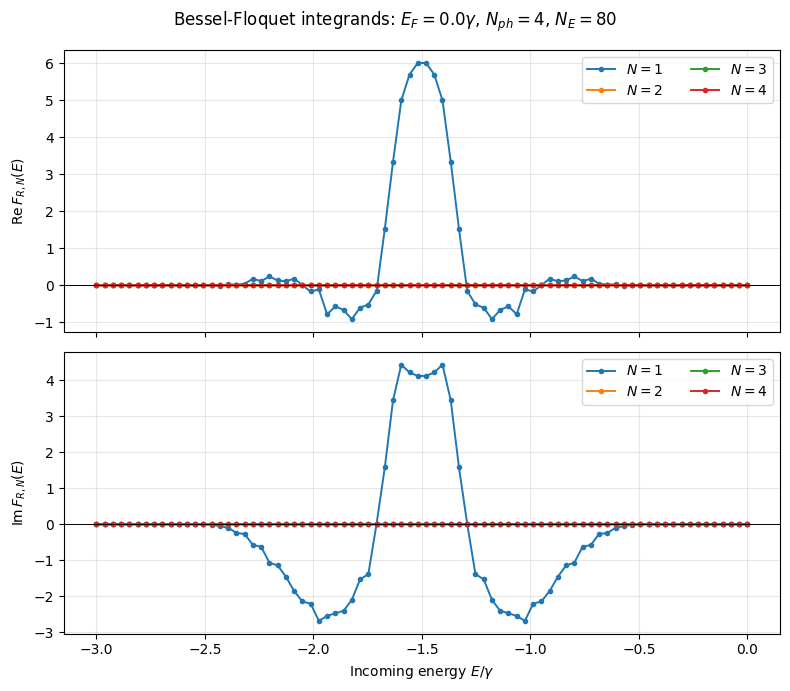

In [44]:
# ============================================================
# Cell E7: Real and imaginary parts of selected
#          right-lead harmonic integrands
# ============================================================

# Plot the first four harmonics.
N_plot_E = N_values_E[
    :min(4, len(N_values_E))
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8.0, 7.0),
    sharex=True
)

for N in N_plot_E:

    # Row corresponding to harmonic order N
    iN = np.where(
        N_values_E == N
    )[0][0]

    # Real part
    axes[0].plot(
        E_grid_E,
        integrands_E["R"][iN].real,
        linewidth=1.4,
        marker="o",
        markersize=3,
        label=rf"$N={N}$"
    )

    # Imaginary part
    axes[1].plot(
        E_grid_E,
        integrands_E["R"][iN].imag,
        linewidth=1.4,
        marker="o",
        markersize=3,
        label=rf"$N={N}$"
    )

axes[0].set_ylabel(
    r"$\mathrm{Re}\,F_{R,N}(E)$"
)

axes[1].set_ylabel(
    r"$\mathrm{Im}\,F_{R,N}(E)$"
)

axes[1].set_xlabel(
    r"Incoming energy $E/\gamma$"
)

for ax in axes:

    ax.axhline(
        0.0,
        color="black",
        linewidth=0.7
    )

    ax.grid(alpha=0.3)

    ax.legend(ncol=2)

fig.suptitle(
    rf"Bessel-Floquet integrands: "
    rf"$E_F={EF_E}\gamma$, "
    rf"$N_{{ph}}={Nph_E}$, "
    rf"$N_E={NE_E}$"
)

plt.tight_layout()
plt.show()

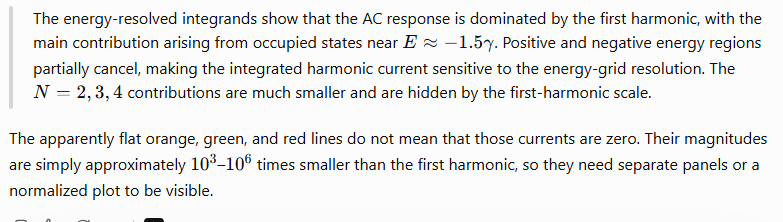

### Cell E8 — Harmonic spectrum and symmetry residual

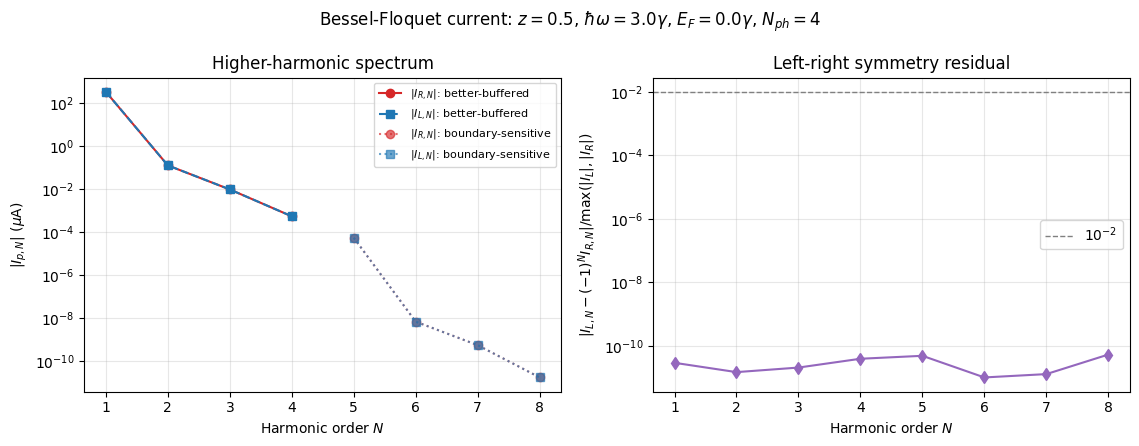

In [45]:
# ============================================================
# Cell E8: Higher-harmonic spectrum for both leads
#          and left-right symmetry residual
# ============================================================

IL_magnitude_E = np.array([
    results_E["L"][int(N)]["magnitude"]
    for N in N_values_E
])

IR_magnitude_E = np.array([
    results_E["R"][int(N)]["magnitude"]
    for N in N_values_E
])

# Orders N <= Nph have a better Floquet-sector buffer.
interior_mask_E = (
    N_values_E <= Nph_E
)

# Orders N > Nph lie closer to the truncation boundary
# and require an Nph-convergence test.
boundary_mask_E = (
    N_values_E > Nph_E
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.5)
)

# ------------------------------------------------------------
# Left panel: higher-harmonic spectrum
# ------------------------------------------------------------

axes[0].semilogy(
    N_values_E[interior_mask_E],
    IR_magnitude_E[interior_mask_E],
    "o-",
    color="tab:red",
    label=r"$|I_{R,N}|$: better-buffered"
)

axes[0].semilogy(
    N_values_E[interior_mask_E],
    IL_magnitude_E[interior_mask_E],
    "s--",
    color="tab:blue",
    label=r"$|I_{L,N}|$: better-buffered"
)

if np.any(boundary_mask_E):

    axes[0].semilogy(
        N_values_E[boundary_mask_E],
        IR_magnitude_E[boundary_mask_E],
        "o:",
        color="tab:red",
        alpha=0.65,
        label=r"$|I_{R,N}|$: boundary-sensitive"
    )

    axes[0].semilogy(
        N_values_E[boundary_mask_E],
        IL_magnitude_E[boundary_mask_E],
        "s:",
        color="tab:blue",
        alpha=0.65,
        label=r"$|I_{L,N}|$: boundary-sensitive"
    )

axes[0].set_xlabel(
    r"Harmonic order $N$"
)

axes[0].set_ylabel(
    r"$|I_{p,N}|$ ($\mu$A)"
)

axes[0].set_title(
    "Higher-harmonic spectrum"
)

axes[0].set_xticks(
    N_values_E
)

axes[0].grid(
    alpha=0.3,
    which="both"
)

axes[0].legend(
    fontsize=8
)

# ------------------------------------------------------------
# Right panel: symmetry residual
# ------------------------------------------------------------

axes[1].semilogy(
    N_values_E,
    np.maximum(
        symmetry_relative_error_E,
        1e-16
    ),
    "d-",
    color="tab:purple"
)

axes[1].axhline(
    1e-2,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label=r"$10^{-2}$"
)

axes[1].set_xlabel(
    r"Harmonic order $N$"
)

axes[1].set_ylabel(
    r"$|I_{L,N}-(-1)^N I_{R,N}|/"
    r"\max(|I_L|,|I_R|)$"
)

axes[1].set_title(
    "Left-right symmetry residual"
)

axes[1].set_xticks(
    N_values_E
)

axes[1].grid(
    alpha=0.3,
    which="both"
)

axes[1].legend()

fig.suptitle(
    rf"Bessel-Floquet current: "
    rf"$z={z}$, "
    rf"$\hbar\omega={omega}\gamma$, "
    rf"$E_F={EF_E}\gamma$, "
    rf"$N_{{ph}}={Nph_E}$"
)

plt.tight_layout()
plt.show()

#### Cell E8a — Separate left- and right-lead spectra

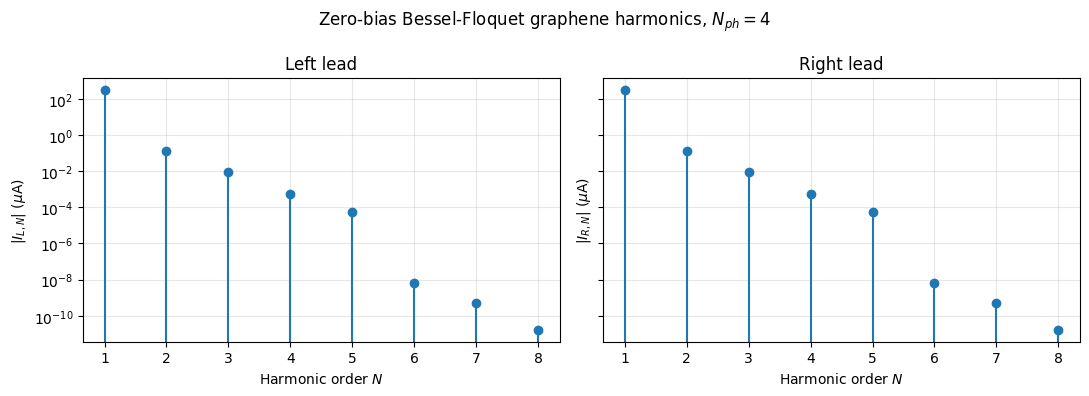

In [47]:
# ============================================================
# Cell E8a: Zero-bias Bessel harmonic spectrum
#            Left panel:  |I_L,N|
#            Right panel: |I_R,N|
# ============================================================

harmonic_orders_E = np.array(
    N_values_E,
    dtype=int
)

harmonic_magnitudes_L_E = np.array([
    results_E["L"][int(N)]["magnitude"]
    for N in harmonic_orders_E
])

harmonic_magnitudes_R_E = np.array([
    results_E["R"][int(N)]["magnitude"]
    for N in harmonic_orders_E
])

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=(11, 4),
    sharey=True
)

# ------------------------------------------------------------
# Left-lead spectrum
# ------------------------------------------------------------

ax_left.stem(
    harmonic_orders_E,
    harmonic_magnitudes_L_E,
    basefmt=" "
)

ax_left.set_yscale("log")

ax_left.set_xlabel(
    r"Harmonic order $N$"
)

ax_left.set_ylabel(
    r"$|I_{L,N}|$ ($\mu$A)"
)

ax_left.set_title(
    "Left lead"
)

ax_left.set_xticks(
    harmonic_orders_E
)

ax_left.grid(
    alpha=0.3,
    which="both"
)

# ------------------------------------------------------------
# Right-lead spectrum
# ------------------------------------------------------------

ax_right.stem(
    harmonic_orders_E,
    harmonic_magnitudes_R_E,
    basefmt=" "
)

ax_right.set_yscale("log")

ax_right.set_xlabel(
    r"Harmonic order $N$"
)

ax_right.set_ylabel(
    r"$|I_{R,N}|$ ($\mu$A)"
)

ax_right.set_title(
    "Right lead"
)

ax_right.set_xticks(
    harmonic_orders_E
)

ax_right.grid(
    alpha=0.3,
    which="both"
)

fig.suptitle(
    rf"Zero-bias Bessel-Floquet graphene harmonics, "
    rf"$N_{{ph}}={Nph_E}$"
)

plt.tight_layout()
plt.show()

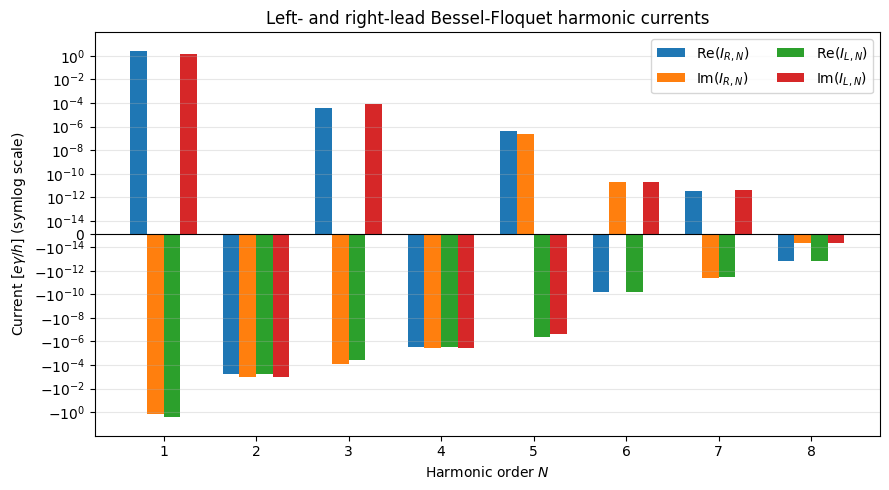

In [48]:
# ============================================================
# Cell E8b: Compare complex I_R,N and I_L,N
#            versus harmonic order
# ============================================================

N_arr_E = np.array(
    N_values_E,
    dtype=int
)

# Complex currents in natural units e*gamma/h
IL_arr_E = np.array([
    results_E["L"][int(N)]["natural"]
    for N in N_arr_E
])

IR_arr_E = np.array([
    results_E["R"][int(N)]["natural"]
    for N in N_arr_E
])

width_E = 0.18

fig, ax = plt.subplots(
    figsize=(9, 5)
)

# Right-lead real and imaginary components
ax.bar(
    N_arr_E - 1.5*width_E,
    IR_arr_E.real,
    width_E,
    label=r"$\mathrm{Re}(I_{R,N})$"
)

ax.bar(
    N_arr_E - 0.5*width_E,
    IR_arr_E.imag,
    width_E,
    label=r"$\mathrm{Im}(I_{R,N})$"
)

# Left-lead real and imaginary components
ax.bar(
    N_arr_E + 0.5*width_E,
    IL_arr_E.real,
    width_E,
    label=r"$\mathrm{Re}(I_{L,N})$"
)

ax.bar(
    N_arr_E + 1.5*width_E,
    IL_arr_E.imag,
    width_E,
    label=r"$\mathrm{Im}(I_{L,N})$"
)

# Symmetric logarithmic scale:
# logarithmic away from zero but able to display
# both positive and negative values.
ax.set_yscale(
    "symlog",
    linthresh=1e-14
)

ax.axhline(
    0.0,
    color="black",
    linewidth=0.8
)

ax.set_xlabel(
    r"Harmonic order $N$"
)

ax.set_ylabel(
    r"Current [$e\gamma/h$] (symlog scale)"
)

ax.set_title(
    "Left- and right-lead Bessel-Floquet harmonic currents"
)

ax.set_xticks(
    N_arr_E
)

ax.grid(
    alpha=0.3,
    axis="y",
    which="both"
)

ax.legend(
    ncol=2
)

plt.tight_layout()
plt.show()

**Complex left- and right-lead harmonic currents.** The real and imaginary parts are the cosine and sine quadratures of each harmonic coefficient $I_{p,N}(t)$

==========

$$
2\mathrm{Re}(I_{p,N})\cos(N\omega t)\\
+\\
2\mathrm{Im}(I_{p,N})\sin(N\omega t).
$$

The combined inversion–half-period symmetry gives

$$
I_{L,N}=(-1)^N I_{R,N}.
$$

Consequently, both quadratures reverse sign between the leads for odd harmonics, while they have the same signs and values for even harmonics. The symmetric-logarithmic scale displays positive and negative components whose magnitudes span many orders.


### Cell E9 — Time-dependent current

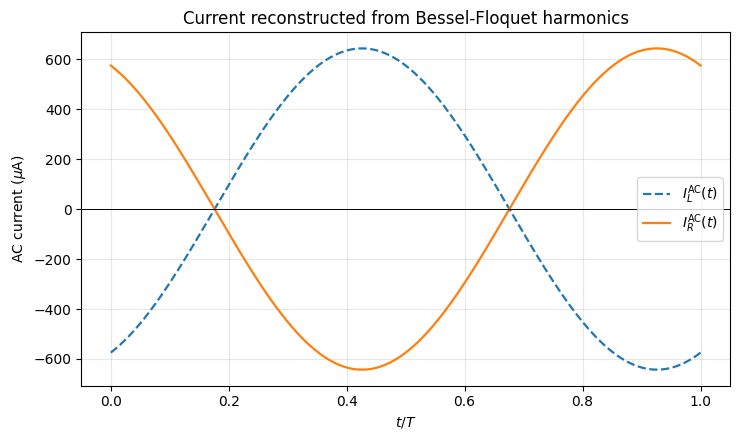

In [46]:
# ============================================================
# Cell E9: Reconstruct the real AC currents over
#          one optical period
# ============================================================

# Dimensionless optical phase:
#
# phase_E = omega*t
#
# One complete period corresponds to 0 <= phase_E <= 2*pi.
phase_E = np.linspace(
    0.0,
    2.0*np.pi,
    500
)

I_time_L_E = np.zeros_like(
    phase_E,
    dtype=float
)

I_time_R_E = np.zeros_like(
    phase_E,
    dtype=float
)

# Reconstruct the real current from the positive-frequency
# coefficients and their complex conjugates:
#
# I_p^AC(t) = 2 Re[sum_{N>0} I_p,N exp(-i N omega t)]
for N in N_values_E:

    N = int(N)

    ILN = results_E["L"][N]["microamp"]
    IRN = results_E["R"][N]["microamp"]

    I_time_L_E += (
        2.0
        * np.real(
            ILN
            * np.exp(-1j*N*phase_E)
        )
    )

    I_time_R_E += (
        2.0
        * np.real(
            IRN
            * np.exp(-1j*N*phase_E)
        )
    )

plt.figure(
    figsize=(7.5, 4.5)
)

plt.plot(
    phase_E/(2.0*np.pi),
    I_time_L_E,
    "--",
    linewidth=1.6,
    label=r"$I_L^{\rm AC}(t)$"
)

plt.plot(
    phase_E/(2.0*np.pi),
    I_time_R_E,
    "-",
    linewidth=1.6,
    label=r"$I_R^{\rm AC}(t)$"
)

plt.axhline(
    0.0,
    color="black",
    linewidth=0.7
)

plt.xlabel(
    r"$t/T$"
)

plt.ylabel(
    r"AC current ($\mu$A)"
)

plt.title(
    "Current reconstructed from Bessel-Floquet harmonics"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Cell E10 — Bessel-only Nph convergence helper

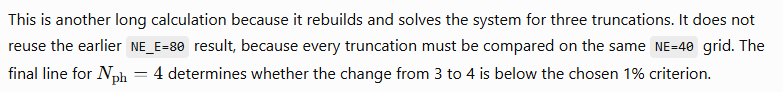

In [49]:
# ============================================================
# Cell E10: Bessel-only Nph convergence helper
# ============================================================

def bessel_harmonic_nph_convergence(
    N_target,
    Nph_values,
    NE=40,
    EF=0.0,
    E_min=-3.0,
    eta=1e-6,
    print_progress=False
):
    """
    Rebuild the analytic Bessel Floquet Hamiltonian for
    every selected Nph and calculate I_R,N_target.

    No numerical phase sampling is used.
    """

    N_target = int(N_target)

    Nph_values = np.asarray(
        Nph_values,
        dtype=int
    )

    currents = np.full(
        len(Nph_values),
        np.nan + 1j*np.nan,
        dtype=complex
    )

    for i, Nph_test in enumerate(Nph_values):

        # A harmonic N requires N <= 2*Nph.
        if N_target > 2*Nph_test:

            print(
                f"Nph={Nph_test}: "
                f"N={N_target} is not representable; skipped."
            )

            continue

        print(
            f"\nBessel convergence: "
            f"N={N_target}, Nph={Nph_test}"
        )

        # ----------------------------------------------------
        # Rebuild analytic Bessel Fourier components
        # ----------------------------------------------------
        H_fourier_test = device_fourier_components(
            Nx=Nx,
            Ny=Ny,
            gamma=gamma,
            z=z,
            Mmax=2*Nph_test
        )

        # ----------------------------------------------------
        # Rebuild Floquet matrices
        # ----------------------------------------------------
        HF_test, OmegaF_test = (
            assemble_floquet_matrices(
                H_fourier=H_fourier_test,
                Nph=Nph_test,
                omega=omega
            )
        )

        # ----------------------------------------------------
        # Calculate only the selected harmonic
        # ----------------------------------------------------
        result_test, _, _, _ = (
            graphene_bessel_harmonic_sweep(
                N_values=[N_target],
                HF=HF_test,
                OmegaF=OmegaF_test,
                H00=H00,
                H01=H01,
                Nx=Nx,
                Nph=Nph_test,
                omega=omega,
                muL=EF,
                muR=EF,
                eta=eta,
                E_min=E_min,
                E_max=EF,
                NE=NE,
                temperature_mode="zero",
                gamma_eV=gamma_eV_E,
                spin_degeneracy=spin_degeneracy_E,
                checkpoint_path=None,
                print_progress=print_progress
            )
        )

        currents[i] = (
            result_test["R"][N_target]["microamp"]
        )

        print(
            f"I_R,{N_target} = "
            f"{currents[i].real:+.6e} "
            f"{currents[i].imag:+.6e}j "
            f"microampere"
        )

        # Release the large matrices before the next Nph.
        del H_fourier_test
        del HF_test
        del OmegaF_test

    # --------------------------------------------------------
    # Consecutive-Nph relative changes
    # --------------------------------------------------------
    relative_change = np.full(
        len(Nph_values),
        np.nan,
        dtype=float
    )

    for i in range(1, len(Nph_values)):

        if (
            np.isfinite(currents[i])
            and np.isfinite(currents[i-1])
        ):

            denominator = max(
                abs(currents[i-1]),
                1e-30
            )

            relative_change[i] = (
                abs(
                    currents[i]
                    - currents[i-1]
                )
                / denominator
            )

    return currents, relative_change


print(
    "Cell E10 loaded. The Nph convergence calculation "
    "has not been started."
)

Cell E10 loaded. The Nph convergence calculation has not been started.


### Cell E11 — Run and plot preliminary Nph convergence


Bessel convergence: N=3, Nph=2
Energy    1/40: E=-3.000000 gamma
Energy   10/40: E=-2.307692 gamma
Energy   20/40: E=-1.538462 gamma
Energy   30/40: E=-0.769231 gamma
Energy   40/40: E=+0.000000 gamma
I_R,3 = +1.701820e-03 -7.530286e-03j microampere

Bessel convergence: N=3, Nph=3
Energy    1/40: E=-3.000000 gamma
Energy   10/40: E=-2.307692 gamma
Energy   20/40: E=-1.538462 gamma
Energy   30/40: E=-0.769231 gamma
Energy   40/40: E=+0.000000 gamma
I_R,3 = +5.071780e-03 -7.871027e-03j microampere

Bessel convergence: N=3, Nph=4
Energy    1/40: E=-3.000000 gamma
Energy   10/40: E=-2.307692 gamma
Energy   20/40: E=-1.538462 gamma
Energy   30/40: E=-0.769231 gamma
Energy   40/40: E=+0.000000 gamma
I_R,3 = +4.305703e-03 -8.100442e-03j microampere

Bessel-Floquet convergence for harmonic N=3
Nph | I_R,N (microampere)                         | |I_R,N| (microampere) | change (%)
----------------------------------------------------------------------------------
  2 | +1.70182028e-03 -7.5302856

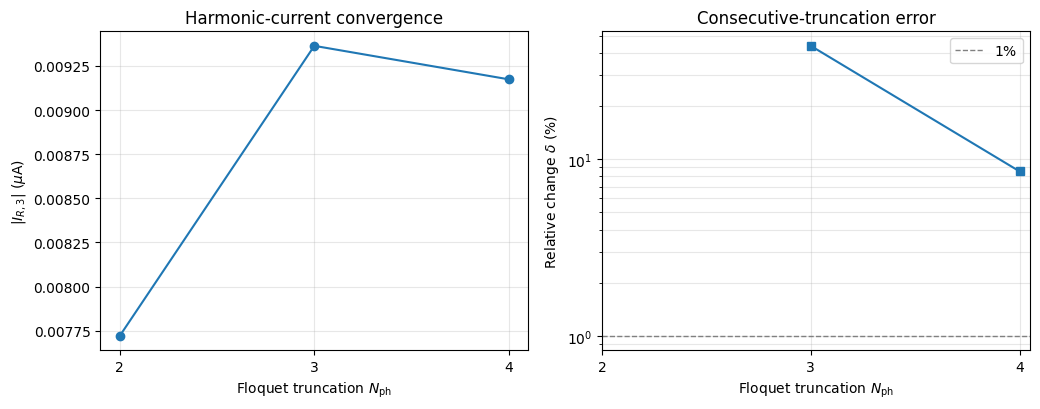

In [50]:
# ============================================================
# Cell E11: Run and plot preliminary Nph convergence
# ============================================================

# Third harmonic:
# Nph=2 is the smallest truncation that can represent N=3.
N_target_E = 3

# Preliminary convergence sequence
Nph_values_check_E = np.array(
    [2, 3, 4],
    dtype=int
)

# Use the same energy grid for every Nph.
NE_convergence_E = 40

currents_Nph_E, relative_change_Nph_E = (
    bessel_harmonic_nph_convergence(
        N_target=N_target_E,
        Nph_values=Nph_values_check_E,
        NE=NE_convergence_E,
        EF=EF_E,
        E_min=Emin_E,
        eta=eta_floquet,
        print_progress=True
    )
)

# Current magnitudes
magnitudes_Nph_E = np.abs(
    currents_Nph_E
)

# Convert relative changes to percentages.
relative_change_percent_E = (
    100.0 * relative_change_Nph_E
)

# ------------------------------------------------------------
# Print convergence table
# ------------------------------------------------------------

print("\n" + "="*82)
print(
    f"Bessel-Floquet convergence for harmonic "
    f"N={N_target_E}"
)
print("="*82)

print(
    "Nph | I_R,N (microampere)                         "
    "| |I_R,N| (microampere) | change (%)"
)

print("-"*82)

for Nph_test, current, magnitude, change in zip(
    Nph_values_check_E,
    currents_Nph_E,
    magnitudes_Nph_E,
    relative_change_percent_E
):

    change_text = (
        "---"
        if np.isnan(change)
        else f"{change:.6e}"
    )

    print(
        f"{Nph_test:3d} | "
        f"{current.real:+.8e} {current.imag:+.8e}j | "
        f"{magnitude:.8e} | "
        f"{change_text}"
    )

print("="*82)

# ------------------------------------------------------------
# Plot convergence
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.2)
)

# Current magnitude versus Nph
axes[0].plot(
    Nph_values_check_E,
    magnitudes_Nph_E,
    "o-",
    linewidth=1.5
)

axes[0].set_xlabel(
    r"Floquet truncation $N_{\rm ph}$"
)

axes[0].set_ylabel(
    rf"$|I_{{R,{N_target_E}}}|$ ($\mu$A)"
)

axes[0].set_title(
    "Harmonic-current convergence"
)

axes[0].set_xticks(
    Nph_values_check_E
)

axes[0].grid(alpha=0.3)

# Relative change between consecutive truncations
axes[1].semilogy(
    Nph_values_check_E,
    relative_change_percent_E,
    "s-",
    linewidth=1.5
)

# One-percent reference criterion
axes[1].axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label=r"$1\%$"
)

axes[1].set_xlabel(
    r"Floquet truncation $N_{\rm ph}$"
)

axes[1].set_ylabel(
    r"Relative change $\delta$ (%)"
)

axes[1].set_title(
    "Consecutive-truncation error"
)

axes[1].set_xticks(
    Nph_values_check_E
)

axes[1].grid(
    alpha=0.3,
    which="both"
)

axes[1].legend()

plt.tight_layout()
plt.show()


Bessel convergence for N=[1, 2], Nph=2
Floquet matrix shape = (8700, 8700)
Expected shape       = (8700, 8700)
Checkpoint           = partE_convergence_N1N2_z0.500_Nph2_NE40_EF+0.000.npz
Energy    1/40: E=-3.000000 gamma
Energy   10/40: E=-2.307692 gamma
Energy   20/40: E=-1.538462 gamma
Energy   30/40: E=-0.769231 gamma
Energy   40/40: E=+0.000000 gamma
Completed Nph=2: 40/40 energies

Bessel convergence for N=[1, 2], Nph=3
Floquet matrix shape = (12180, 12180)
Expected shape       = (12180, 12180)
Checkpoint           = partE_convergence_N1N2_z0.500_Nph3_NE40_EF+0.000.npz
Energy    1/40: E=-3.000000 gamma
Energy   10/40: E=-2.307692 gamma
Energy   20/40: E=-1.538462 gamma
Energy   30/40: E=-0.769231 gamma
Energy   40/40: E=+0.000000 gamma
Completed Nph=3: 40/40 energies

Bessel convergence for N=[1, 2], Nph=4
Floquet matrix shape = (15660, 15660)
Expected shape       = (15660, 15660)
Checkpoint           = partE_convergence_N1N2_z0.500_Nph4_NE40_EF+0.000.npz
Energy    1/40: E=-3.000

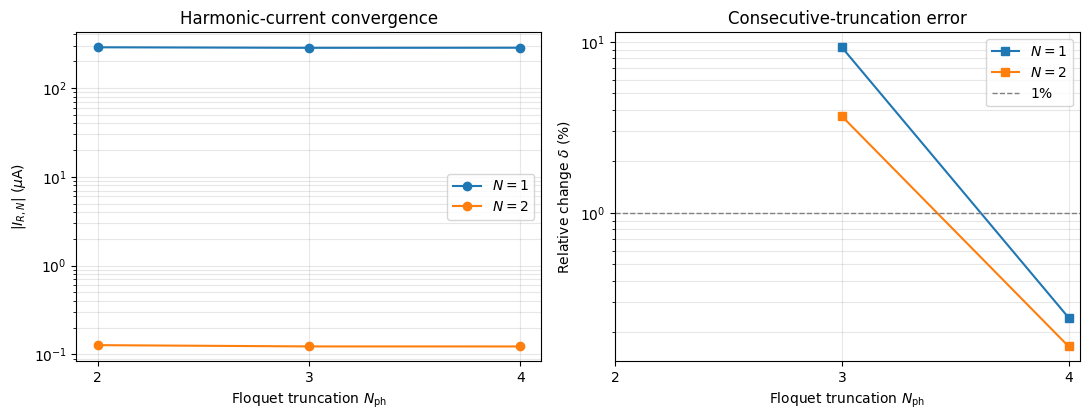

In [52]:
# ============================================================
# Cell E11b: Corrected Nph convergence for N=1 and N=2
#             Nph = 2, 3, 4
#             Common energy grid: NE = 40
# ============================================================

N_values_low_E = np.array(
    [1, 2],
    dtype=int
)

Nph_values_low_E = np.array(
    [2, 3, 4],
    dtype=int
)

# Must match the energy grid used in Cell E11.
NE_low_convergence_E = 40

# Rows correspond to N=1,2.
# Columns correspond to Nph=2,3,4.
currents_R_low_E = np.zeros(
    (
        len(N_values_low_E),
        len(Nph_values_low_E)
    ),
    dtype=complex
)

currents_L_low_E = np.zeros_like(
    currents_R_low_E
)

# ------------------------------------------------------------
# Run each Floquet truncation
# ------------------------------------------------------------

for j, Nph_test in enumerate(Nph_values_low_E):

    print("\n" + "="*70)

    print(
        f"Bessel convergence for N={N_values_low_E.tolist()}, "
        f"Nph={Nph_test}"
    )

    print("="*70)

    # Analytic Bessel Fourier components
    H_fourier_low_E = device_fourier_components(
        Nx=Nx,
        Ny=Ny,
        gamma=gamma,
        z=z,
        Mmax=2*Nph_test
    )

    # Floquet Hamiltonian
    HF_low_E, OmegaF_low_E = (
        assemble_floquet_matrices(
            H_fourier=H_fourier_low_E,
            Nph=Nph_test,
            omega=omega
        )
    )

    expected_dim_low_E = (
        (2*Nph_test + 1)
        * Nx
        * N_orb
    )

    print(
        "Floquet matrix shape =",
        HF_low_E.shape
    )

    print(
        "Expected shape       =",
        (
            expected_dim_low_E,
            expected_dim_low_E
        )
    )

    # A separate checkpoint is used for every Nph.
    checkpoint_low_E = (
        f"partE_convergence_N1N2_"
        f"z{z:.3f}_Nph{Nph_test}_"
        f"NE{NE_low_convergence_E}_"
        f"EF{EF_E:+.3f}.npz"
    )

    print(
        "Checkpoint           =",
        checkpoint_low_E
    )

    # Calculate N=1 and N=2 together.
    results_low_E, E_grid_low_E, integrands_low_E, done_low_E = (
        graphene_bessel_harmonic_sweep(
            N_values=N_values_low_E,
            HF=HF_low_E,
            OmegaF=OmegaF_low_E,
            H00=H00,
            H01=H01,
            Nx=Nx,
            Nph=Nph_test,
            omega=omega,
            muL=EF_E,
            muR=EF_E,
            eta=eta_floquet,
            E_min=Emin_E,
            E_max=EF_E,
            NE=NE_low_convergence_E,
            temperature_mode="zero",
            gamma_eV=gamma_eV_E,
            spin_degeneracy=spin_degeneracy_E,
            checkpoint_path=checkpoint_low_E,
            print_progress=True
        )
    )

    # Store both lead currents.
    for i, N in enumerate(N_values_low_E):

        N = int(N)

        currents_R_low_E[i, j] = (
            results_low_E["R"][N]["microamp"]
        )

        currents_L_low_E[i, j] = (
            results_low_E["L"][N]["microamp"]
        )

    print(
        f"Completed Nph={Nph_test}: "
        f"{int(done_low_E.sum())}/"
        f"{NE_low_convergence_E} energies"
    )

    # Release the large matrices before constructing the next Nph.
    del H_fourier_low_E
    del HF_low_E
    del OmegaF_low_E
    del results_low_E
    del E_grid_low_E
    del integrands_low_E
    del done_low_E


# ============================================================
# Calculate consecutive-Nph relative changes
# ============================================================

relative_change_R_low_E = np.full(
    currents_R_low_E.shape,
    np.nan,
    dtype=float
)

for i in range(len(N_values_low_E)):

    for j in range(
        1,
        len(Nph_values_low_E)
    ):

        previous_current = (
            currents_R_low_E[i, j-1]
        )

        current = (
            currents_R_low_E[i, j]
        )

        relative_change_R_low_E[i, j] = (
            abs(current - previous_current)
            / max(
                abs(previous_current),
                1e-30
            )
        )

relative_change_percent_R_low_E = (
    100.0 * relative_change_R_low_E
)


# ============================================================
# Print separate convergence tables for N=1 and N=2
# ============================================================

for i, N in enumerate(N_values_low_E):

    N = int(N)

    print("\n" + "="*88)

    print(
        f"Bessel-Floquet convergence for harmonic N={N}"
    )

    print("="*88)

    print(
        "Nph | I_R,N (microampere)                         "
        "| |I_R,N| (microampere) | change (%)"
    )

    print("-"*88)

    for j, Nph_test in enumerate(
        Nph_values_low_E
    ):

        current = currents_R_low_E[i, j]
        magnitude = abs(current)
        change = relative_change_percent_R_low_E[i, j]

        change_text = (
            "---"
            if np.isnan(change)
            else f"{change:.6e}"
        )

        print(
            f"{Nph_test:3d} | "
            f"{current.real:+.8e} "
            f"{current.imag:+.8e}j | "
            f"{magnitude:.8e} | "
            f"{change_text}"
        )

    print("="*88)


# ============================================================
# Plot convergence for N=1 and N=2
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.3)
)

colors_low_E = [
    "tab:blue",
    "tab:orange"
]

# Current magnitudes
for i, N in enumerate(N_values_low_E):

    axes[0].semilogy(
        Nph_values_low_E,
        np.abs(currents_R_low_E[i]),
        "o-",
        color=colors_low_E[i],
        label=rf"$N={N}$"
    )

axes[0].set_xlabel(
    r"Floquet truncation $N_{\rm ph}$"
)

axes[0].set_ylabel(
    r"$|I_{R,N}|$ ($\mu$A)"
)

axes[0].set_title(
    "Harmonic-current convergence"
)

axes[0].set_xticks(
    Nph_values_low_E
)

axes[0].grid(
    alpha=0.3,
    which="both"
)

axes[0].legend()

# Consecutive-truncation errors
for i, N in enumerate(N_values_low_E):

    axes[1].semilogy(
        Nph_values_low_E,
        relative_change_percent_R_low_E[i],
        "s-",
        color=colors_low_E[i],
        label=rf"$N={N}$"
    )

axes[1].axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label=r"$1\%$"
)

axes[1].set_xlabel(
    r"Floquet truncation $N_{\rm ph}$"
)

axes[1].set_ylabel(
    r"Relative change $\delta$ (%)"
)

axes[1].set_title(
    "Consecutive-truncation error"
)

axes[1].set_xticks(
    Nph_values_low_E
)

axes[1].grid(
    alpha=0.3,
    which="both"
)

axes[1].legend()

plt.tight_layout()
plt.show()

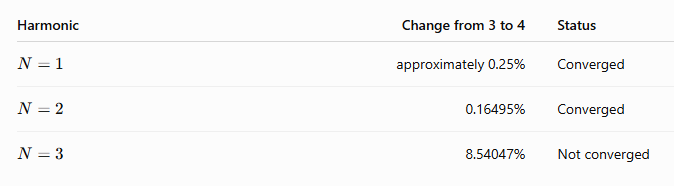

Building Bessel Floquet matrices for N=3, Nph=5
Floquet matrix shape = (19140, 19140)
Expected shape       = (19140, 19140)
Checkpoint           = partE_convergence_N3_Nph5_NE40.npz
Resuming checkpoint: 2/40 energies already complete
Energy   10/40: E=-2.307692 gamma
Energy   20/40: E=-1.538462 gamma
Energy   30/40: E=-0.769231 gamma
Energy   40/40: E=+0.000000 gamma

Extended Bessel-Floquet convergence: N=3
Nph | I_R,N (microampere)                         | |I_R,N| (microampere) | change (%)
------------------------------------------------------------------------------------
  2 | +1.70182028e-03 -7.53028563e-03j | 7.72019390e-03 | ---
  3 | +5.07178013e-03 -7.87102671e-03j | 9.36354715e-03 | 4.387380e+01
  4 | +4.30570315e-03 -8.10044185e-03j | 9.17367089e-03 | 8.540468e+00
  5 | +4.30644184e-03 -8.09905227e-03j | 9.17279069e-03 | 1.715470e-02


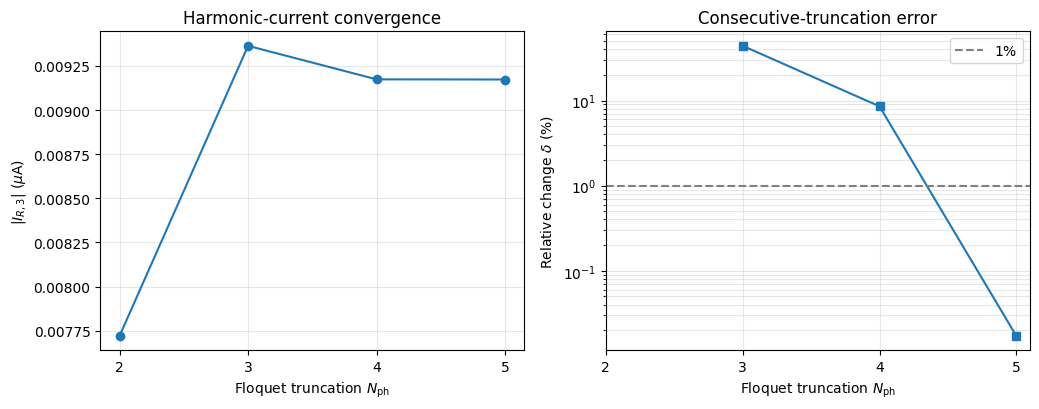

In [53]:
# ============================================================
# Cell E12: Extend N=3 convergence to Nph=5 only
#            with checkpointing
# ============================================================

N_target_E12 = 3
Nph_extra_E12 = 5

# Must match the grid used in Cell E11.
NE_extra_E12 = NE_convergence_E

checkpoint_E12 = (
    f"partE_convergence_N{N_target_E12}_"
    f"Nph{Nph_extra_E12}_NE{NE_extra_E12}.npz"
)

print(
    f"Building Bessel Floquet matrices for "
    f"N={N_target_E12}, Nph={Nph_extra_E12}"
)

# ------------------------------------------------------------
# Analytic Bessel Fourier components
# ------------------------------------------------------------

H_fourier_E12 = device_fourier_components(
    Nx=Nx,
    Ny=Ny,
    gamma=gamma,
    z=z,
    Mmax=2*Nph_extra_E12
)

# ------------------------------------------------------------
# Floquet Hamiltonian
# ------------------------------------------------------------

HF_E12, OmegaF_E12 = assemble_floquet_matrices(
    H_fourier=H_fourier_E12,
    Nph=Nph_extra_E12,
    omega=omega
)

expected_dimension_E12 = (
    (2*Nph_extra_E12 + 1)
    * Nx
    * N_orb
)

print(
    "Floquet matrix shape =",
    HF_E12.shape
)

print(
    "Expected shape       =",
    (
        expected_dimension_E12,
        expected_dimension_E12
    )
)

print(
    "Checkpoint           =",
    checkpoint_E12
)

# ------------------------------------------------------------
# Calculate only N=3 at Nph=5
# ------------------------------------------------------------

result_E12, E_grid_E12, integrands_E12, done_E12 = (
    graphene_bessel_harmonic_sweep(
        N_values=[N_target_E12],
        HF=HF_E12,
        OmegaF=OmegaF_E12,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph_extra_E12,
        omega=omega,
        muL=EF_E,
        muR=EF_E,
        eta=eta_floquet,
        E_min=Emin_E,
        E_max=EF_E,
        NE=NE_extra_E12,
        temperature_mode="zero",
        gamma_eV=gamma_eV_E,
        spin_degeneracy=spin_degeneracy_E,
        checkpoint_path=checkpoint_E12,
        print_progress=True
    )
)

current_Nph5_E = (
    result_E12["R"][N_target_E12]["microamp"]
)

# ------------------------------------------------------------
# Combine Nph=5 with the completed E11 results
# ------------------------------------------------------------

Nph_values_extended_E = np.append(
    Nph_values_check_E,
    Nph_extra_E12
)

currents_Nph_extended_E = np.append(
    currents_Nph_E,
    current_Nph5_E
)

magnitudes_Nph_extended_E = np.abs(
    currents_Nph_extended_E
)

relative_change_extended_E = np.full(
    len(Nph_values_extended_E),
    np.nan,
    dtype=float
)

for i in range(
    1,
    len(Nph_values_extended_E)
):

    relative_change_extended_E[i] = (
        abs(
            currents_Nph_extended_E[i]
            - currents_Nph_extended_E[i-1]
        )
        / max(
            abs(currents_Nph_extended_E[i-1]),
            1e-30
        )
    )

relative_change_percent_extended_E = (
    100.0 * relative_change_extended_E
)

# ------------------------------------------------------------
# Print extended convergence table
# ------------------------------------------------------------

print("\n" + "="*84)

print(
    f"Extended Bessel-Floquet convergence: "
    f"N={N_target_E12}"
)

print("="*84)

print(
    "Nph | I_R,N (microampere)                         "
    "| |I_R,N| (microampere) | change (%)"
)

print("-"*84)

for Nph_test, current, magnitude, change in zip(
    Nph_values_extended_E,
    currents_Nph_extended_E,
    magnitudes_Nph_extended_E,
    relative_change_percent_extended_E
):

    change_text = (
        "---"
        if np.isnan(change)
        else f"{change:.6e}"
    )

    print(
        f"{Nph_test:3d} | "
        f"{current.real:+.8e} {current.imag:+.8e}j | "
        f"{magnitude:.8e} | "
        f"{change_text}"
    )

print("="*84)

# ------------------------------------------------------------
# Updated convergence plots
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.2)
)

axes[0].plot(
    Nph_values_extended_E,
    magnitudes_Nph_extended_E,
    "o-"
)

axes[0].set_xlabel(
    r"Floquet truncation $N_{\rm ph}$"
)

axes[0].set_ylabel(
    rf"$|I_{{R,{N_target_E12}}}|$ ($\mu$A)"
)

axes[0].set_title(
    "Harmonic-current convergence"
)

axes[0].set_xticks(
    Nph_values_extended_E
)

axes[0].grid(alpha=0.3)

axes[1].semilogy(
    Nph_values_extended_E,
    relative_change_percent_extended_E,
    "s-"
)

axes[1].axhline(
    1.0,
    color="gray",
    linestyle="--",
    label=r"$1\%$"
)

axes[1].set_xlabel(
    r"Floquet truncation $N_{\rm ph}$"
)

axes[1].set_ylabel(
    r"Relative change $\delta$ (%)"
)

axes[1].set_title(
    "Consecutive-truncation error"
)

axes[1].set_xticks(
    Nph_values_extended_E
)

axes[1].grid(
    alpha=0.3,
    which="both"
)

axes[1].legend()

plt.tight_layout()
plt.show()

In [1]:
# ============================================================
# Cell E11c: Separate convergence plots for N=1 and N=2
# ============================================================

for i, N in enumerate(N_values_low_E):

    N = int(N)

    magnitudes_N = np.abs(
        currents_R_low_E[i]
    )

    plt.figure(
        figsize=(5.2, 4.2)
    )

    plt.plot(
        Nph_values_low_E,
        magnitudes_N,
        "o-",
        linewidth=1.5
    )

    plt.xlabel(
        r"Floquet truncation $N_{\rm ph}$"
    )

    plt.ylabel(
        rf"$|I_{{R,{N}}}|$ ($\mu$A)"
    )

    plt.title(
        rf"Harmonic-current convergence: $N={N}$"
    )

    plt.xticks(
        Nph_values_low_E
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

NameError: name 'N_values_low_E' is not defined

## Part F, finite bias



Part F investigates how a finite source–drain bias modifies the graphene higher-harmonic currents. The three cases considered are

$$
V_b=0,\qquad V_b=0.01,\qquad V_b=0.1.
$$

The Floquet truncation used previously in Parts B–E remains unchanged:

$$
N_{\mathrm{ph}}=4.
$$

Part F introduces an independent truncation,

$$
N_{\mathrm{ph},F}=5,
$$

because the zero-bias convergence analysis showed that the third harmonic requires five photon sectors on either side of the central sector. The corresponding Bessel Fourier components and Floquet matrices must therefore be rebuilt as `H_fourier_F`, `HF_F`, and `OmegaF_F`. The matrices previously constructed with `Nph = 4` cannot be used in a calculation that passes `Nph_F = 5`, because their dimensions and retained Floquet sectors are different.

For a controlled comparison, all three bias cases are evaluated using the same numerical and physical parameters:

$$
N_{\mathrm{ph},F}=5,\qquad
N_E=\text{constant},\qquad
E_F= \hbar\omega /2,\qquad
z=0.5,\qquad
\hbar\omega=3\gamma.
$$

Using identical parameters ensures that changes in the harmonic spectrum are caused by the applied bias rather than by different Floquet truncations or energy grids.

A symmetric voltage drop is used:

$$
\mu_L=E_F+\frac{V_b}{2},
\qquad
\mu_R=E_F-\frac{V_b}{2}.
$$

Thus, the bias difference is

$$
\mu_L-\mu_R=V_b.
$$


| $E_F$ | $V_b$ | Purpose                           |
| ----- | ----: | --------------------------------- |
| 0     |     0 | compare with Part E               |
| 0     |  0.01 | finite bias near CNP              |
| 0     |   0.1 | stronger finite bias near CNP     |
| 1.5   |     0 | zero-bias reference at $\Delta_1$ |
| 1.5   |  0.01 | small-bias Floquet-TI case        |
| 1.5   |   0.1 | stronger-bias Floquet-TI case     |


### Cell F1 — Independent Part F setup

In [32]:
# ============================================================
# PART F — FINITE-BIAS HIGHER HARMONICS
# Cell F1: Parameters
# ============================================================

# Independent Floquet truncation for Part F
Nph_F = 5

# Fermi energies to compare
EF_values_F = np.array([
    0.0,
    omega / 2
])

# Bias values to compare
Vb_values_F = np.array([
    0.0,
    0.01,
    0.1
])

# Harmonics to calculate
N_list_F = [1, 2, 3, 4, 5]

print("Part F parameters")
print("-----------------")
print("Part B Nph remains =", Nph)
print("Part F Nph         =", Nph_F)
print("Part F sectors     =", np.arange(-Nph_F, Nph_F + 1))
print("Harmonics          =", N_list_F)
print("EF values          =", EF_values_F)
print("Bias values        =", Vb_values_F)

print("\nCases to calculate:")
for EF in EF_values_F:
    for Vb in Vb_values_F:
        muL = EF + Vb / 2
        muR = EF - Vb / 2

        print(
            f"EF={EF:.3f}, Vb={Vb:.3f}: "
            f"muL={muL:+.5f}, muR={muR:+.5f}"
        )

Part F parameters
-----------------
Part B Nph remains = 4
Part F Nph         = 5
Part F sectors     = [-5 -4 -3 -2 -1  0  1  2  3  4  5]
Harmonics          = [1, 2, 3, 4, 5]
EF values          = [0.  1.5]
Bias values        = [0.   0.01 0.1 ]

Cases to calculate:
EF=0.000, Vb=0.000: muL=+0.00000, muR=+0.00000
EF=0.000, Vb=0.010: muL=+0.00500, muR=-0.00500
EF=0.000, Vb=0.100: muL=+0.05000, muR=-0.05000
EF=1.500, Vb=0.000: muL=+1.50000, muR=+1.50000
EF=1.500, Vb=0.010: muL=+1.50500, muR=+1.49500
EF=1.500, Vb=0.100: muL=+1.55000, muR=+1.45000


### Cell F2: Independent Bessel-Floquet matrices for Part F

In [33]:
# ============================================================
# PART F — FINITE-BIAS HIGHER HARMONICS
# Cell F2: Build independent Bessel-Floquet matrices for Nph_F
# ============================================================

print("Building Part F Bessel Fourier components...")

# We need Fourier orders up to +/- 2*Nph_F
# because HF contains couplings H_(n-m).
H_fourier_F = device_fourier_components(
    Nx=Nx,
    Ny=Ny,
    gamma=gamma,
    z=z,
    Mmax=2 * Nph_F
)

print(
    "Part F Fourier orders =",
    sorted(H_fourier_F.keys())
)

print("\nBuilding Part F Floquet matrices...")

HF_F, OmegaF_F = assemble_floquet_matrices(
    H_fourier=H_fourier_F,
    Nph=Nph_F,
    omega=omega
)

# Expected Floquet-Sambe dimension
expected_dim_F = (
    (2 * Nph_F + 1)
    * Nx
    * N_orb
)

print("\nPart F matrix check")
print("-------------------")

print(
    "HF_F shape       =",
    HF_F.shape
)

print(
    "Expected shape   =",
    (expected_dim_F, expected_dim_F)
)

print(
    "OmegaF_F shape   =",
    OmegaF_F.shape
)

print(
    "Hermiticity error =",
    np.linalg.norm(
        HF_F - HF_F.conj().T
    )
)

Building Part F Bessel Fourier components...
Part F Fourier orders = [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Building Part F Floquet matrices...

Part F matrix check
-------------------
HF_F shape       = (19140, 19140)
Expected shape   = (19140, 19140)
OmegaF_F shape   = (19140, 19140)
Hermiticity error = 0.0


### Cell F3: Energy grids for both Fermi energies

In [44]:
# ============================================================
# PART F — FINITE-BIAS HIGHER HARMONICS
# Cell F3: Final energy grids
# ============================================================

Emin_F = -3.0

# Target spacing: same as Part E, about 3/79
dE_target_F = 3.0 / 79.0

energy_grids_F = {}
NE_by_EF_F = {}

for EF in EF_values_F:

    # Highest occupied chemical potential among the biases
    mu_max = np.max(EF + Vb_values_F / 2.0)

    Emax = mu_max

    # Keep approximately the same energy resolution
    NE_here = int(
        round((Emax - Emin_F) / dE_target_F)
    ) + 1

    energies = np.linspace(
        Emin_F,
        Emax,
        NE_here
    )

    energy_grids_F[float(EF)] = energies
    NE_by_EF_F[float(EF)] = NE_here

    print(f"\nEF = {EF:.3f}")
    print("----------------------")
    print(f"Emin      = {Emin_F:+.5f}")
    print(f"Emax      = {Emax:+.5f}")
    print(f"NE        = {NE_here}")
    print(
        f"dE approx = "
        f"{energies[1] - energies[0]:.5f}"
    )


EF = 0.000
----------------------
Emin      = -3.00000
Emax      = +0.05000
NE        = 81
dE approx = 0.03812

EF = 1.500
----------------------
Emin      = -3.00000
Emax      = +1.55000
NE        = 121
dE approx = 0.03792


### Cell F4: Harmonic-current integrand at one energy



This cell defines the harmonic-current integrand at a single energy $E$ for the Part F setup.

For each energy, the Floquet scattering matrices are calculated using the independent Part F Floquet system with

$$
N_{\rm ph}^{(F)} = 5.
$$

At finite bias, the two reservoirs have different chemical potentials,

$$
\mu_L = E_F + \frac{V_b}{2},
\qquad
\mu_R = E_F - \frac{V_b}{2},
$$

and therefore their occupations are generally different,

$$
f_L(E) \neq f_R(E).
$$

This is the main new ingredient compared with the zero-bias calculation in Part E.

The function evaluates the contributions to the left and right harmonic currents for each requested harmonic $N$ by summing over the incoming leads and the allowed Floquet sectors $m$ and $m+N$.

Importantly, this cell explicitly uses the Part F objects `HF_F`, `OmegaF_F`, and `Nph_F`, so the finite-bias calculation is performed with $N_{\rm ph}=5$ independently of the $N_{\rm ph}=4$ setup used previously in Part E.

This F4 is consistent with Part E implementation. It uses the same scattering formalism, but substitutes:

HF      -> HF_F

OmegaF  -> OmegaF_F

Nph     -> Nph_F



In [ ]:
# ============================================================
# PART F — FINITE-BIAS HIGHER HARMONICS
# Cell F4: Harmonic-current integrand at one energy
# Adapted from Part E
# ============================================================

def graphene_bessel_harmonic_integrands_at_energy_F(
    E,
    muL,
    muR,
    N_list,
):
    """
    Calculate the complex harmonic-current integrands
    F_L,N(E) and F_R,N(E) for Part F.

    Uses the independent Part-F Floquet system:
        HF_F
        OmegaF_F
        Nph_F = 5
    """

    # --------------------------------------------------------
    # Validate requested harmonics
    # --------------------------------------------------------
    N_values = validate_positive_harmonics(
        N_values=N_list,
        Nph=Nph_F
    )

    # --------------------------------------------------------
    # Zero-temperature reservoir occupations
    # --------------------------------------------------------
    fL = reservoir_occupation_E(
        E=E,
        mu=muL,
        temperature_mode="zero"
    )

    fR = reservoir_occupation_E(
        E=E,
        mu=muR,
        temperature_mode="zero"
    )

    # If neither reservoir occupies this incoming energy,
    # all harmonic contributions are zero.
    if fL == 0.0 and fR == 0.0:
        return {
            int(N): (
                0.0 + 0.0j,
                0.0 + 0.0j
            )
            for N in N_values
        }

    # --------------------------------------------------------
    # Contact Green-function blocks for Part F
    # --------------------------------------------------------
    G_by_m, _, _ = graphene_contact_green_blocks(
        E=E,
        HF=HF_F,
        OmegaF=OmegaF_F,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph_F,
        omega=omega,
        eta=eta_floquet
    )

    # --------------------------------------------------------
    # Floquet scattering matrices
    # --------------------------------------------------------
    S_by_m, _ = build_graphene_scattering_matrices(
        G_by_m=G_by_m,
        E=E,
        H00=H00,
        H01=H01,
        omega=omega,
        eta=eta_floquet
    )

    sectors = sorted(S_by_m)

    out = {}

    # --------------------------------------------------------
    # Construct each current harmonic
    # --------------------------------------------------------
    for N in N_values:

        N = int(N)

        IL_N = 0.0 + 0.0j
        IR_N = 0.0 + 0.0j

        for m in sectors:

            mpN = m + N

            # Both sectors must exist in the retained
            # Floquet truncation.
            if mpN not in S_by_m:
                continue

            Sm = S_by_m[m]
            SmN = S_by_m[mpN]

            # -----------------------------------------------
            # LEFT-lead current harmonic
            # -----------------------------------------------
            IL_N += fL * np.trace(
                Sm["LL"].conj().T
                @ SmN["LL"]
            )

            IL_N += fR * np.trace(
                Sm["LR"].conj().T
                @ SmN["LR"]
            )

            # -----------------------------------------------
            # RIGHT-lead current harmonic
            # -----------------------------------------------
            IR_N += fL * np.trace(
                Sm["RL"].conj().T
                @ SmN["RL"]
            )

            IR_N += fR * np.trace(
                Sm["RR"].conj().T
                @ SmN["RR"]
            )

        out[N] = (
            IL_N,
            IR_N
        )

    return out


print(
    "F4 loaded: corrected finite-bias "
    "harmonic integrand function."
)

F4 loaded: corrected finite-bias harmonic integrand function.


### Cell F5: Energy sweep for one (EF, Vb) case

In [42]:
# ============================================================
# PART F — FINITE-BIAS HIGHER HARMONICS
# Cell F5: Energy sweep for one (EF, Vb) case
# ============================================================

def graphene_bessel_harmonic_sweep_F(
    EF,
    Vb,
    energies,
    N_list
):
    """
    Compute energy-resolved harmonic-current integrands
    for one (EF, Vb) case.

    Returns
    -------
    data : dict
        data[N]["IL"] : complex array versus energy
        data[N]["IR"] : complex array versus energy
    """

    muL = EF + Vb / 2.0
    muR = EF - Vb / 2.0

    # Storage for each harmonic
    data = {
        N: {
            "IL": np.zeros(len(energies), dtype=complex),
            "IR": np.zeros(len(energies), dtype=complex),
        }
        for N in N_list
    }

    print(
        f"Starting sweep: EF={EF:.3f}, Vb={Vb:.3f}, "
        f"muL={muL:+.5f}, muR={muR:+.5f}"
    )

    for iE, E in enumerate(energies):

        vals = graphene_bessel_harmonic_integrands_at_energy_F(
            E=E,
            muL=muL,
            muR=muR,
            N_list=N_list,
        )

        for N in N_list:
            data[N]["IL"][iE] = vals[N][0]
            data[N]["IR"][iE] = vals[N][1]

        # Progress report
        if (
            iE == 0
            or (iE + 1) % 10 == 0
            or iE == len(energies) - 1
        ):
            print(
                f"  {iE + 1:3d}/{len(energies)} energies completed"
            )

    return data


print("F5 loaded: Part F energy-sweep function.")

F5 loaded: Part F energy-sweep function.


### Cell F6 : Run and checkpoint all six $(E_F,V_b)$ cases

This cell performs the full energy sweep for the two Fermi energies

$$
E_F=0,
\qquad
E_F=\frac{\hbar\omega}{2}=1.5,
$$

and the three bias voltages

$$
V_b=0,\quad 0.01,\quad 0.1.
$$

Thus, six independent calculations are performed using the same Part F Floquet truncation,

$$
N_{\rm ph}^{(F)}=5,
$$

and the same numerical resolution, `NE_F = 80`.

For every completed $(E_F,V_b)$ case, the energy-resolved left and right harmonic-current integrands are saved immediately to a separate checkpoint file. The checkpoint also stores the physical and numerical parameters of that calculation.

Checkpointing does not modify, average, smooth, or integrate the calculated currents. It only protects the expensive numerical results against a kernel restart.

The zero-bias case at $E_F=0$ is calculated again in Part F because Part E used $N_{\rm ph}=4$, whereas all Part F cases use $N_{\rm ph}=5$. This provides an internally consistent reference for comparison with the finite-bias results.

In [ ]:
# ============================================================
# PART F — FINITE-BIAS HIGHER HARMONICS
# Cell F6: Resumable calculation with checkpoints
# ============================================================

import os

checkpoint_dir_F = "partF_checkpoints"
os.makedirs(checkpoint_dir_F, exist_ok=True)

# Rebuild the in-memory collection.
# Existing checkpoints will be loaded automatically.
partF_raw = {}

print("Starting / resuming Part F calculations")
print("=======================================")

case_number = 0
total_cases = len(EF_values_F) * len(Vb_values_F)

for EF in EF_values_F:

    EF_key = float(EF)
    energies = energy_grids_F[EF_key]

    for Vb in Vb_values_F:

        Vb_key = float(Vb)
        case_number += 1

        muL = EF + Vb / 2.0
        muR = EF - Vb / 2.0

        checkpoint_file = os.path.join(
            checkpoint_dir_F,
            f"partF_EF{EF:+.3f}_Vb{Vb:.3f}_"
            f"Nph{Nph_F}_NE{len(energies)}.npz"
        )

        print("\n" + "=" * 62)
        print(
            f"CASE {case_number}/{total_cases}: "
            f"EF={EF:.3f}, Vb={Vb:.3f}"
        )
        print(f"muL = {muL:+.5f}")
        print(f"muR = {muR:+.5f}")
        print(f"NE  = {len(energies)}")
        print("=" * 62)

        # ====================================================
        # If checkpoint exists, load it and skip recalculation
        # ====================================================
        if os.path.exists(checkpoint_file):

            print("Existing checkpoint found.")
            print("Loading instead of recalculating...")

            ckpt = np.load(
                checkpoint_file,
                allow_pickle=False
            )

            # Basic safety checks
            if int(ckpt["Nph_F"]) != int(Nph_F):
                raise ValueError(
                    "Checkpoint Nph does not match current Nph_F."
                )

            saved_energies = np.array(
                ckpt["energies"]
            )

            if not np.allclose(
                saved_energies,
                energies
            ):
                raise ValueError(
                    "Checkpoint energy grid does not match "
                    "the current grid."
                )

            data = {}

            for N in N_list_F:

                N = int(N)

                data[N] = {
                    "IL": np.array(
                        ckpt[f"IL_N{N}"],
                        dtype=complex
                    ),
                    "IR": np.array(
                        ckpt[f"IR_N{N}"],
                        dtype=complex
                    ),
                }

            partF_raw[(EF_key, Vb_key)] = {
                "energies": saved_energies.copy(),
                "data": data
            }

            ckpt.close()

            print("Checkpoint loaded successfully.")
            print("Case skipped.")

            continue

        # ====================================================
        # Otherwise perform the expensive calculation
        # ====================================================
        print("No checkpoint found.")
        print("Running energy sweep...")

        data = graphene_bessel_harmonic_sweep_F(
            EF=EF,
            Vb=Vb,
            energies=energies,
            N_list=N_list_F
        )

        partF_raw[(EF_key, Vb_key)] = {
            "energies": energies.copy(),
            "data": data
        }

        # ====================================================
        # Save completed case
        # ====================================================
        save_dict = {
            "EF": float(EF),
            "Vb": float(Vb),
            "muL": float(muL),
            "muR": float(muR),
            "Nph_F": int(Nph_F),
            "NE_F": int(len(energies)),
            "omega": float(omega),
            "z": float(z),
            "Nx": int(Nx),
            "Ny": int(Ny),
            "N_list_F": np.array(
                N_list_F,
                dtype=int
            ),
            "energies": np.array(energies),
        }

        for N in N_list_F:

            N = int(N)

            save_dict[f"IL_N{N}"] = np.array(
                data[N]["IL"],
                dtype=complex
            )

            save_dict[f"IR_N{N}"] = np.array(
                data[N]["IR"],
                dtype=complex
            )

        np.savez(
            checkpoint_file,
            **save_dict
        )

        print("\nCheckpoint saved:")
        print(checkpoint_file)


print("\n===================================")
print("All Part F energy sweeps completed.")
print("===================================")

print("\nCases available in memory:")

for key in partF_raw:
    print(" ", key)

Starting / resuming Part F calculations

CASE 1/6: EF=0.000, Vb=0.000
muL = +0.00000
muR = +0.00000
NE  = 81
No checkpoint found.
Running energy sweep...
Starting sweep: EF=0.000, Vb=0.000, muL=+0.00000, muR=+0.00000
    1/81 energies completed
   10/81 energies completed
   20/81 energies completed
   30/81 energies completed
   40/81 energies completed
   50/81 energies completed
   60/81 energies completed
   70/81 energies completed
   80/81 energies completed
   81/81 energies completed

Checkpoint saved:
partF_checkpoints/partF_EF+0.000_Vb0.000_Nph5_NE81.npz

CASE 2/6: EF=0.000, Vb=0.010
muL = +0.00500
muR = -0.00500
NE  = 81
No checkpoint found.
Running energy sweep...
Starting sweep: EF=0.000, Vb=0.010, muL=+0.00500, muR=-0.00500
    1/81 energies completed
   10/81 energies completed
   20/81 energies completed
   30/81 energies completed
   40/81 energies completed
   50/81 energies completed
   60/81 energies completed
   70/81 energies completed
   80/81 energies completed


### Cell F7: Integrate the harmonic currents

The expensive calculation in F6 stores the complex energy-resolved harmonic-current integrands for each of the six $(E_F,V_b)$ cases.

This cell performs only the final numerical integration over incoming energy,

$$
I_{p,N}
=
2\int dE\,F_{p,N}(E),
$$

where the factor of 2 accounts for graphene spin degeneracy.

Because the energy variable is expressed in units of $\gamma$, the currents are converted to microamperes using

$$
\frac{e}{h}\gamma
=
38.74\,\gamma_{\rm eV}\;\mu{\rm A},
$$

with

$$
\gamma_{\rm eV}=2.7.
$$

The same integration and current-conversion convention used in Part E is retained here so that the Part E and Part F results can be compared consistently.

No additional Floquet calculation is performed in this cell.

we should get:


Integrated cases = 6

Expected cases   = 6

In [ ]:
# ============================================================
# PART F — FINITE-BIAS HIGHER HARMONICS
# Cell F7: Integrate all six completed energy sweeps
# ============================================================

gamma_eV_F = 2.7
spin_degeneracy_F = 2

# Same conversion used in Part E:
# (e/h) * gamma[eV] -> microampere
conversion_F = 38.74 * gamma_eV_F

trapz_F = (
    np.trapezoid
    if hasattr(np, "trapezoid")
    else np.trapz
)

partF_results = {}

for EF in EF_values_F:

    for Vb in Vb_values_F:

        key = (float(EF), float(Vb))

        if key not in partF_raw:
            raise RuntimeError(
                f"Missing Part F raw data for EF={EF}, Vb={Vb}. "
                "F6 must finish successfully before F7 can run."
            )

        energies = partF_raw[key]["energies"]
        data = partF_raw[key]["data"]

        case_results = {
            "L": {},
            "R": {}
        }

        for N in N_list_F:

            N = int(N)

            IL_natural = (
                spin_degeneracy_F
                * trapz_F(
                    data[N]["IL"],
                    energies
                )
            )

            IR_natural = (
                spin_degeneracy_F
                * trapz_F(
                    data[N]["IR"],
                    energies
                )
            )

            IL_uA = conversion_F * IL_natural
            IR_uA = conversion_F * IR_natural

            case_results["L"][N] = {
                "natural": IL_natural,
                "microamp": IL_uA,
                "magnitude": abs(IL_uA)
            }

            case_results["R"][N] = {
                "natural": IR_natural,
                "microamp": IR_uA,
                "magnitude": abs(IR_uA)
            }

        partF_results[key] = case_results


print("F7 completed.")
print("Integrated cases =", len(partF_results))
print("Expected cases   =", len(EF_values_F) * len(Vb_values_F))

### Cell8: Individual harmonic spectra for all Part F cases

This cell plots the higher-harmonic spectrum separately for every combination of Fermi energy and bias voltage.

For each case, separate spectra are shown for the left and right leads:

$$
|I_{L,N}|
$$

and

$$
|I_{R,N}|.
$$

The harmonic order is

$$
N=1,\ldots,5,
$$

and a logarithmic vertical scale is used to display the large variation in harmonic-current magnitude.

The calculation includes both

$$
E_F=0
$$

and

$$
E_F=\frac{\hbar\omega}{2}=1.5,
$$

for

$$
V_b=0,\quad0.01,\quad0.1.
$$

Thus, twelve individual harmonic-spectrum plots are produced in total: six parameter cases for each of the two leads.

In [ ]:
# ============================================================
# Cell 8: Individual harmonic spectra for every Part F case
# 6 cases x 2 leads = 12 plots
# ============================================================

N_arr_F = np.array(N_list_F, dtype=int)

for EF in EF_values_F:

    for Vb in Vb_values_F:

        key = (float(EF), float(Vb))

        # ====================================================
        # LEFT LEAD
        # ====================================================

        IL_mag = np.array([
            partF_results[key]["L"][int(N)]["magnitude"]
            for N in N_arr_F
        ])

        plt.figure(figsize=(7.0, 4.8))

        plt.stem(
            N_arr_F,
            IL_mag
        )

        plt.yscale("log")

        plt.xlabel(r"Harmonic order $N$")
        plt.ylabel(r"$|I_{L,N}|$ ($\mu$A)")

        plt.title(
            rf"Graphene harmonics: "
            rf"$E_F={EF:g}\gamma$, "
            rf"$V_b={Vb:g}$, "
            rf"$N_{{ph}}={Nph_F}$"
        )

        plt.xticks(N_arr_F)
        plt.grid(alpha=0.3, which="both")
        plt.tight_layout()
        plt.show()


        # ====================================================
        # RIGHT LEAD
        # ====================================================

        IR_mag = np.array([
            partF_results[key]["R"][int(N)]["magnitude"]
            for N in N_arr_F
        ])

        plt.figure(figsize=(7.0, 4.8))

        plt.stem(
            N_arr_F,
            IR_mag
        )

        plt.yscale("log")

        plt.xlabel(r"Harmonic order $N$")
        plt.ylabel(r"$|I_{R,N}|$ ($\mu$A)")

        plt.title(
            rf"Graphene harmonics: "
            rf"$E_F={EF:g}\gamma$, "
            rf"$V_b={Vb:g}$, "
            rf"$N_{{ph}}={Nph_F}$"
        )

        plt.xticks(N_arr_F)
        plt.grid(alpha=0.3, which="both")
        plt.tight_layout()
        plt.show()

### Cell F9: Numerical harmonic-current tables

This cell prints the complex left- and right-lead harmonic currents for every calculated combination of Fermi energy and bias.

For each harmonic,

$$
I_{p,N}
=
\operatorname{Re}I_{p,N}
+
i\,\operatorname{Im}I_{p,N},
$$

and the magnitude is

$$
|I_{p,N}|
=
\sqrt{
(\operatorname{Re}I_{p,N})^2+
(\operatorname{Im}I_{p,N})^2
}.
$$

At zero bias, the left-right symmetry relation found in Part E can be examined again. At finite bias, however, the same zero-bias relation is not imposed; the left and right currents are reported independently.

This will give six separate tables.

In [ ]:
# ============================================================
# Cell F9: Print complex harmonic-current tables
# ============================================================

for EF in EF_values_F:

    for Vb in Vb_values_F:

        key = (float(EF), float(Vb))
        results = partF_results[key]

        print("\n" + "=" * 112)
        print(
            f"EF = {EF:.3f}, Vb = {Vb:.3f}, "
            f"Nph = {Nph_F}, NE = {NE_F}"
        )
        print("=" * 112)

        print(
            " N |                 I_L,N (microampere) |"
            "                 I_R,N (microampere) |"
            "      |I_L,N| |      |I_R,N|"
        )

        print("-" * 112)

        for N in N_list_F:

            N = int(N)

            IL = results["L"][N]["microamp"]
            IR = results["R"][N]["microamp"]

            print(
                f"{N:2d} | "
                f"{IL.real:+.8e} {IL.imag:+.8e}j | "
                f"{IR.real:+.8e} {IR.imag:+.8e}j | "
                f"{abs(IL):.6e} | "
                f"{abs(IR):.6e}"
            )

        print("=" * 112)

### Cell F10: Harmonic spectra versus bias

This cell compares the magnitude of the harmonic currents,

$$
|I_{p,N}|,
$$

for the three bias voltages

$$
V_b=0,\qquad 0.01,\qquad 0.1,
$$

at both

$$
E_F=0
$$

and

$$
E_F=\frac{\hbar\omega}{2}=1.5.
$$

The left and right leads are displayed separately. A logarithmic vertical scale is used because the harmonic intensities can span several orders of magnitude.

These plots provide the main comparison of how finite bias modifies the harmonic spectrum at the charge-neutral point and at the center of the dynamical Floquet gap.

In [ ]:
# ============================================================
# Cell F10: Harmonic spectra for all EF and Vb values
# ============================================================

N_arr_F = np.array(N_list_F, dtype=int)

for EF in EF_values_F:

    # ========================================================
    # LEFT LEAD
    # ========================================================

    plt.figure(figsize=(7.0, 4.8))

    for Vb in Vb_values_F:

        key = (float(EF), float(Vb))

        magnitudes = np.array([
            partF_results[key]["L"][int(N)]["magnitude"]
            for N in N_arr_F
        ])

        plt.semilogy(
            N_arr_F,
            magnitudes,
            marker="o",
            linewidth=1.5,
            label=rf"$V_b={Vb:g}$"
        )

    plt.xlabel(r"Harmonic order $N$")
    plt.ylabel(r"$|I_{L,N}|$ ($\mu$A)")

    plt.title(
        rf"Left-lead harmonics: $E_F={EF:g}\gamma$"
    )

    plt.xticks(N_arr_F)
    plt.grid(alpha=0.3, which="both")
    plt.legend()

    plt.tight_layout()
    plt.show()


    # ========================================================
    # RIGHT LEAD
    # ========================================================

    plt.figure(figsize=(7.0, 4.8))

    for Vb in Vb_values_F:

        key = (float(EF), float(Vb))

        magnitudes = np.array([
            partF_results[key]["R"][int(N)]["magnitude"]
            for N in N_arr_F
        ])

        plt.semilogy(
            N_arr_F,
            magnitudes,
            marker="o",
            linewidth=1.5,
            label=rf"$V_b={Vb:g}$"
        )

    plt.xlabel(r"Harmonic order $N$")
    plt.ylabel(r"$|I_{R,N}|$ ($\mu$A)")

    plt.title(
        rf"Right-lead harmonics: $E_F={EF:g}\gamma$"
    )

    plt.xticks(N_arr_F)
    plt.grid(alpha=0.3, which="both")
    plt.legend()

    plt.tight_layout()
    plt.show()

### Cell F11:Effect of the Fermi energy

This cell directly compares the harmonic spectrum at

$$
E_F=0
$$

and

$$
E_F=\frac{\hbar\omega}{2}=1.5
$$

for each applied bias.

The comparison separates two different physical effects:

1. modification of the harmonics by the source-drain bias;
2. modification caused by changing the electronic filling from the charge-neutral region to the dynamical Floquet-gap region.

The right-lead current is used for this comparison, while the corresponding left-lead currents remain available from the previous cells.

In [ ]:
# ============================================================
# Cell F11: Direct EF comparison for each bias
# ============================================================

for Vb in Vb_values_F:

    plt.figure(figsize=(7.0, 4.8))

    for EF in EF_values_F:

        key = (float(EF), float(Vb))

        magnitudes = np.array([
            partF_results[key]["R"][int(N)]["magnitude"]
            for N in N_arr_F
        ])

        plt.semilogy(
            N_arr_F,
            magnitudes,
            marker="o",
            linewidth=1.5,
            label=rf"$E_F={EF:g}\gamma$"
        )

    plt.xlabel(r"Harmonic order $N$")
    plt.ylabel(r"$|I_{R,N}|$ ($\mu$A)")

    plt.title(
        rf"Fermi-energy comparison: $V_b={Vb:g}$"
    )

    plt.xticks(N_arr_F)
    plt.grid(alpha=0.3, which="both")
    plt.legend()

    plt.tight_layout()
    plt.show()

### Cell F12: Zero-bias left-right symmetry check

The combined inversion and half-period symmetry previously examined in Part E predicts, at zero bias,

$$
I_{L,N}=(-1)^N I_{R,N}.
$$

Therefore,

$$
I_{L,N}=-I_{R,N}
$$

for odd $N$, while

$$
I_{L,N}=I_{R,N}
$$

for even $N$.

This cell checks this relation only for the two $V_b=0$ calculations in Part F. The same condition is not imposed on the finite-bias results.

In [ ]:
# ============================================================
# Cell F12: Zero-bias symmetry diagnostic
# ============================================================

Vb_zero_F = 0.0

for EF in EF_values_F:

    key = (float(EF), Vb_zero_F)

    print("\n" + "=" * 78)
    print(
        f"Zero-bias symmetry check: EF={EF:.3f}"
    )
    print("=" * 78)

    print(
        " N | relative error in "
        "I_L,N - (-1)^N I_R,N"
    )

    print("-" * 78)

    for N in N_list_F:

        N = int(N)

        IL = partF_results[key]["L"][N]["microamp"]
        IR = partF_results[key]["R"][N]["microamp"]

        residual = IL - ((-1)**N) * IR

        scale = max(
            abs(IL),
            abs(IR),
            1e-30
        )

        relative_error = abs(residual) / scale

        print(
            f"{N:2d} | {relative_error:.6e}"
        )

    print("=" * 78)

### Cell F13:  Left- and right-lead harmonic currents

This cell directly compares the complex harmonic currents in the left and right leads for every combination of Fermi energy and bias voltage.

For each $(E_F,V_b)$ case, the real and imaginary parts of

$$
I_{L,N}
$$

and

$$
I_{R,N}
$$

are plotted as functions of harmonic order $N$.

At zero bias, the plots can be compared with the symmetry relation found in Part E,

$$
I_{L,N}=(-1)^N I_{R,N}.
$$

At finite bias, this relation is not assumed. Instead, the calculated left and right currents are shown independently so that the effect of broken left-right occupation symmetry caused by

$$
\mu_L\neq\mu_R
$$

can be examined directly.

In [ ]:
# ============================================================
# Cell F13: Left/right harmonic-current comparison
# for all EF and Vb values
# ============================================================

N_arr_F = np.array(N_list_F, dtype=int)

for EF in EF_values_F:

    for Vb in Vb_values_F:

        key = (float(EF), float(Vb))

        IL = np.array([
            partF_results[key]["L"][int(N)]["microamp"]
            for N in N_arr_F
        ])

        IR = np.array([
            partF_results[key]["R"][int(N)]["microamp"]
            for N in N_arr_F
        ])

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12, 4.5)
        )

        # ----------------------------------------------------
        # Real parts
        # ----------------------------------------------------
        axes[0].plot(
            N_arr_F,
            IL.real,
            "o-",
            label=r"$I_{L,N}$"
        )

        axes[0].plot(
            N_arr_F,
            IR.real,
            "s--",
            label=r"$I_{R,N}$"
        )

        axes[0].axhline(
            0.0,
            linewidth=0.8
        )

        axes[0].set_xlabel(
            r"Harmonic order $N$"
        )

        axes[0].set_ylabel(
            r"$\mathrm{Re}\,I_N$ ($\mu$A)"
        )

        axes[0].set_title(
            "Real part"
        )

        axes[0].set_xticks(
            N_arr_F
        )

        axes[0].grid(
            alpha=0.3
        )

        axes[0].legend()

        # ----------------------------------------------------
        # Imaginary parts
        # ----------------------------------------------------
        axes[1].plot(
            N_arr_F,
            IL.imag,
            "o-",
            label=r"$I_{L,N}$"
        )

        axes[1].plot(
            N_arr_F,
            IR.imag,
            "s--",
            label=r"$I_{R,N}$"
        )

        axes[1].axhline(
            0.0,
            linewidth=0.8
        )

        axes[1].set_xlabel(
            r"Harmonic order $N$"
        )

        axes[1].set_ylabel(
            r"$\mathrm{Im}\,I_N$ ($\mu$A)"
        )

        axes[1].set_title(
            "Imaginary part"
        )

        axes[1].set_xticks(
            N_arr_F
        )

        axes[1].grid(
            alpha=0.3
        )

        axes[1].legend()

        fig.suptitle(
            rf"$E_F={EF:g}\gamma,\quad V_b={Vb:g}$",
            y=1.02
        )

        plt.tight_layout()
        plt.show()

### Cell F14: Pairwise bias comparison of the harmonic spectra

This cell compares the magnitude of the higher-harmonic currents for different applied bias voltages.

For each Fermi energy,

$$
E_F=0
$$

and

$$
E_F=\frac{\hbar\omega}{2}=1.5,
$$

four bias comparisons are shown:

$$
V_b=0 \quad \mathrm{vs.} \quad V_b=0.01,
$$

$$
V_b=0 \quad \mathrm{vs.} \quad V_b=0.1,
$$

$$
V_b=0.01 \quad \mathrm{vs.} \quad V_b=0.1,
$$

and finally all three bias values together.

Each figure contains two panels. The left panel shows

$$
|I_{L,N}|,
$$

while the right panel shows

$$
|I_{R,N}|.
$$

A logarithmic vertical scale is used because the harmonic-current magnitudes span several orders of magnitude.

These plots provide a direct visualization of how increasing the dc bias changes the harmonic spectrum in each lead and how this dependence differs between the two Fermi energies.

In [ ]:
# ============================================================
# Cell F14: Bias-to-bias harmonic spectrum comparisons
#
# 8 figures total:
#   4 bias comparisons for EF = 0
#   4 bias comparisons for EF = omega/2 = 1.5
#
# Each figure:
#   LEFT  panel -> |I_L,N|
#   RIGHT panel -> |I_R,N|
# ============================================================

N_arr_F = np.array(N_list_F, dtype=int)


# ------------------------------------------------------------
# Bias comparison sets
# ------------------------------------------------------------

bias_comparisons_F = [

    (
        [0.0, 0.01],
        r"$V_b=0$ vs $V_b=0.01$"
    ),

    (
        [0.0, 0.1],
        r"$V_b=0$ vs $V_b=0.1$"
    ),

    (
        [0.01, 0.1],
        r"$V_b=0.01$ vs $V_b=0.1$"
    ),

    (
        [0.0, 0.01, 0.1],
        r"$V_b=0,\ 0.01,\ 0.1$"
    ),
]


# ------------------------------------------------------------
# Loop over both Fermi energies
# ------------------------------------------------------------

for EF in EF_values_F:

    for bias_list, comparison_title in bias_comparisons_F:

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12, 4.8)
        )

        # ====================================================
        # LEFT LEAD
        # ====================================================

        for Vb in bias_list:

            key = (
                float(EF),
                float(Vb)
            )

            IL_mag = np.array([
                partF_results[key]["L"][int(N)]["magnitude"]
                for N in N_arr_F
            ])

            axes[0].semilogy(
                N_arr_F,
                IL_mag,
                marker="o",
                linewidth=1.5,
                label=rf"$V_b={Vb:g}$"
            )

        axes[0].set_xlabel(
            r"Harmonic order $N$"
        )

        axes[0].set_ylabel(
            r"$|I_{L,N}|$ ($\mu$A)"
        )

        axes[0].set_title(
            "Left lead"
        )

        axes[0].set_xticks(
            N_arr_F
        )

        axes[0].grid(
            alpha=0.3,
            which="both"
        )

        axes[0].legend()


        # ====================================================
        # RIGHT LEAD
        # ====================================================

        for Vb in bias_list:

            key = (
                float(EF),
                float(Vb)
            )

            IR_mag = np.array([
                partF_results[key]["R"][int(N)]["magnitude"]
                for N in N_arr_F
            ])

            axes[1].semilogy(
                N_arr_F,
                IR_mag,
                marker="s",
                linewidth=1.5,
                label=rf"$V_b={Vb:g}$"
            )

        axes[1].set_xlabel(
            r"Harmonic order $N$"
        )

        axes[1].set_ylabel(
            r"$|I_{R,N}|$ ($\mu$A)"
        )

        axes[1].set_title(
            "Right lead"
        )

        axes[1].set_xticks(
            N_arr_F
        )

        axes[1].grid(
            alpha=0.3,
            which="both"
        )

        axes[1].legend()


        # ====================================================
        # Overall title
        # ====================================================

        fig.suptitle(
            rf"$E_F={EF:g}\gamma$: "
            + comparison_title,
            fontsize=14
        )

        plt.tight_layout(
            rect=[0, 0, 1, 0.94]
        )

        plt.show()